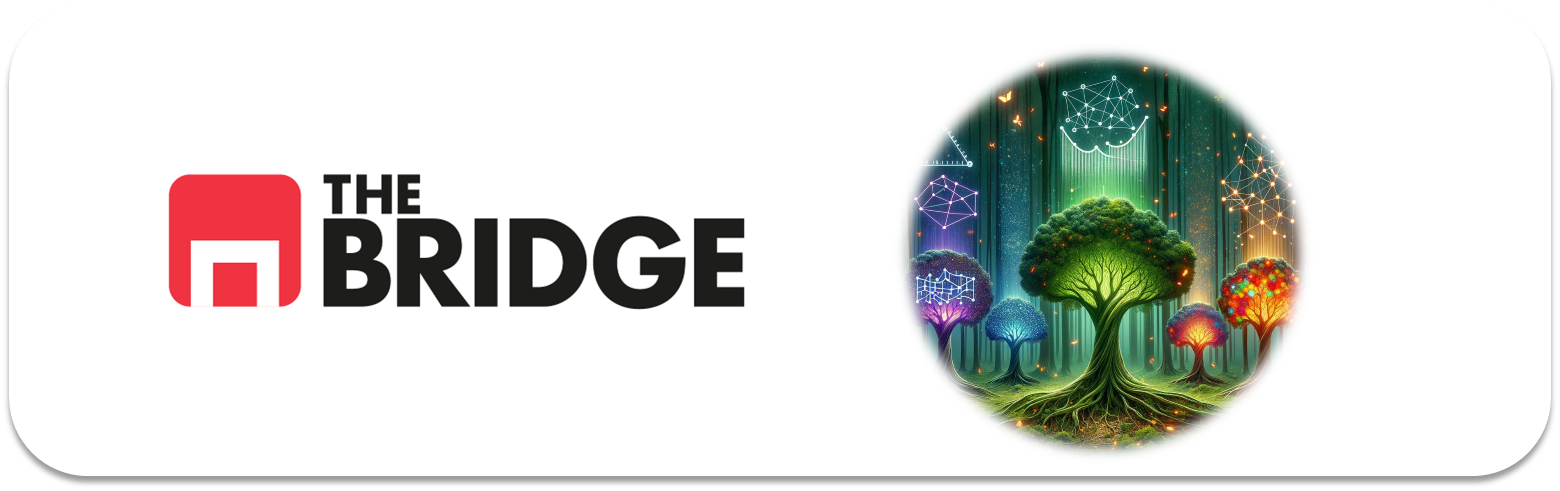

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [144]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn import model_selection, tree, linear_model, metrics, utils

from bootcampviztools import pinta_distribucion_categoricas, plot_categorical_relationship_fin, plot_grouped_histograms

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

In [145]:
df = pd.read_csv('./data/bank-full.csv', sep=';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [146]:
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [147]:
target = 'y'

In [148]:
df[target] = df[target] == 'yes'

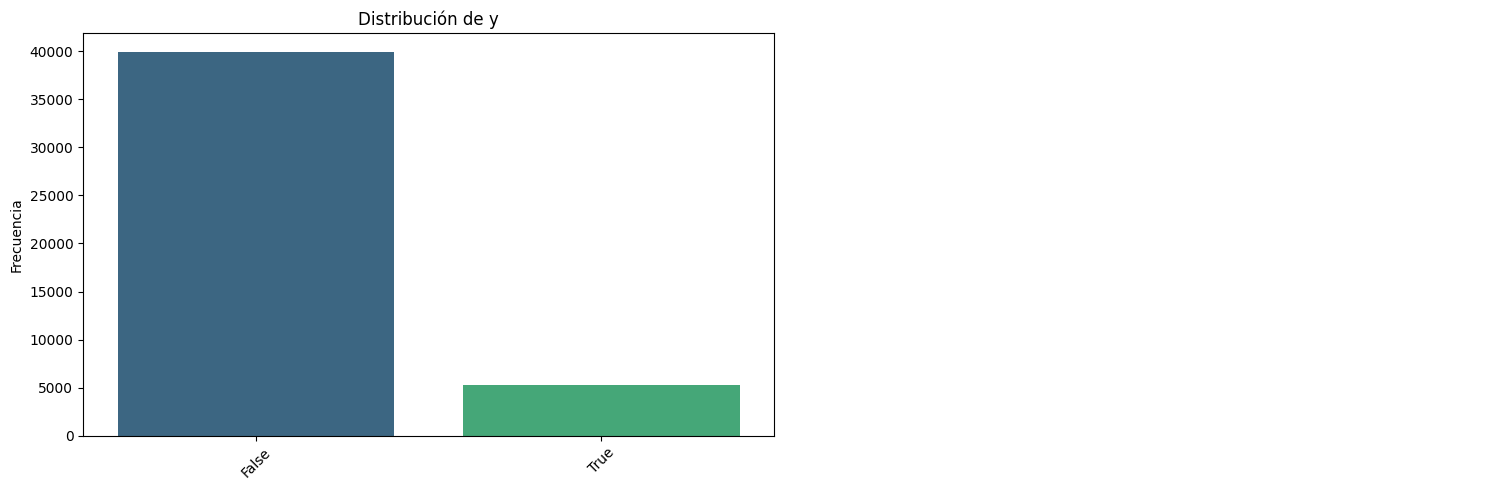

In [149]:
pinta_distribucion_categoricas(df, target)

In [150]:
train, test = model_selection.train_test_split(df, test_size=0.2, random_state=42, stratify=df[target])

In [151]:
col_num = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
col_cat = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

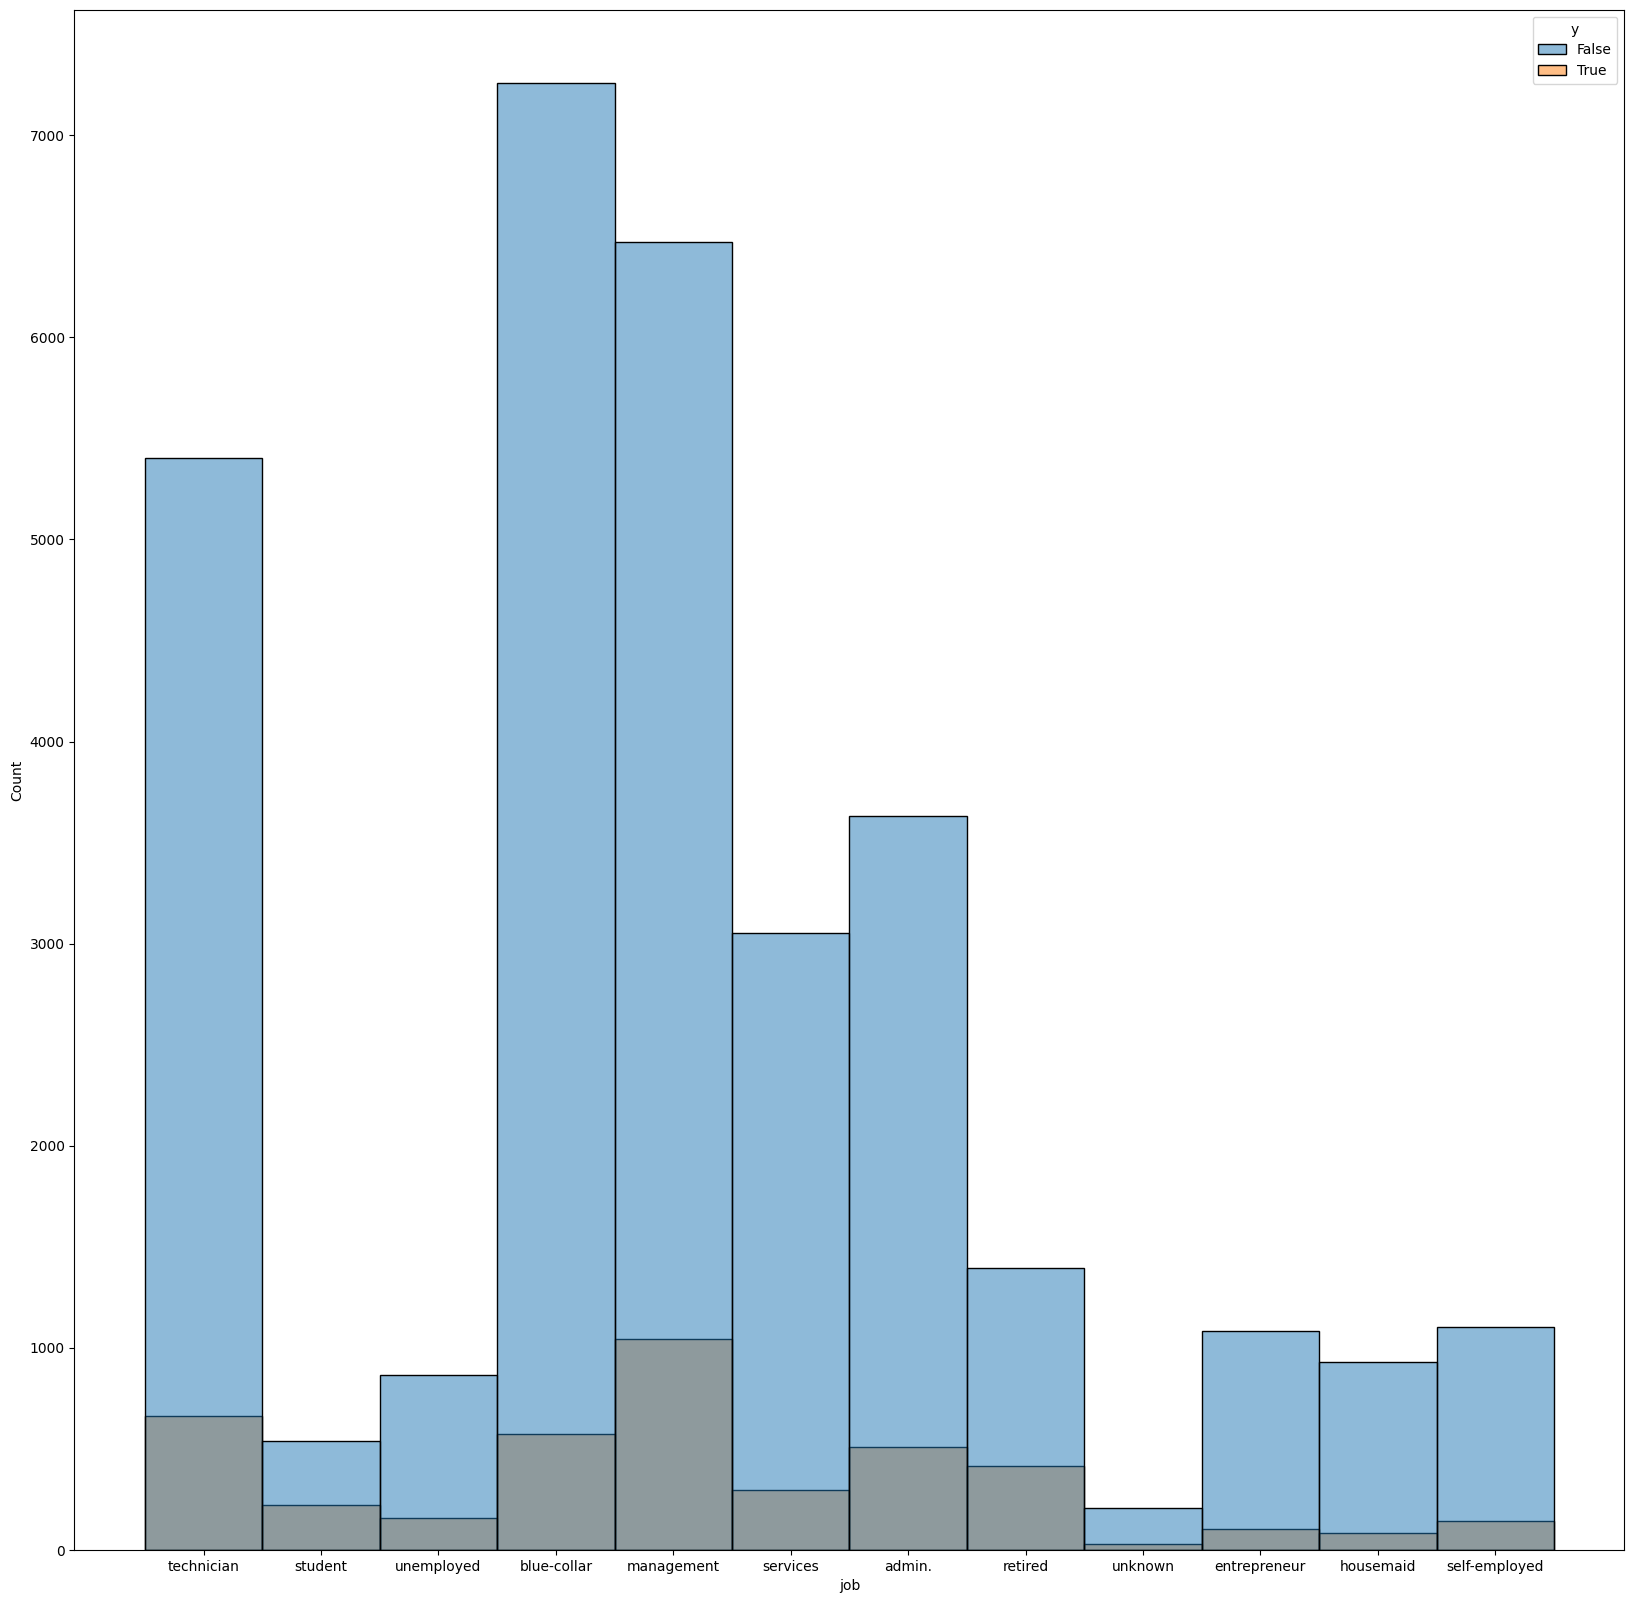

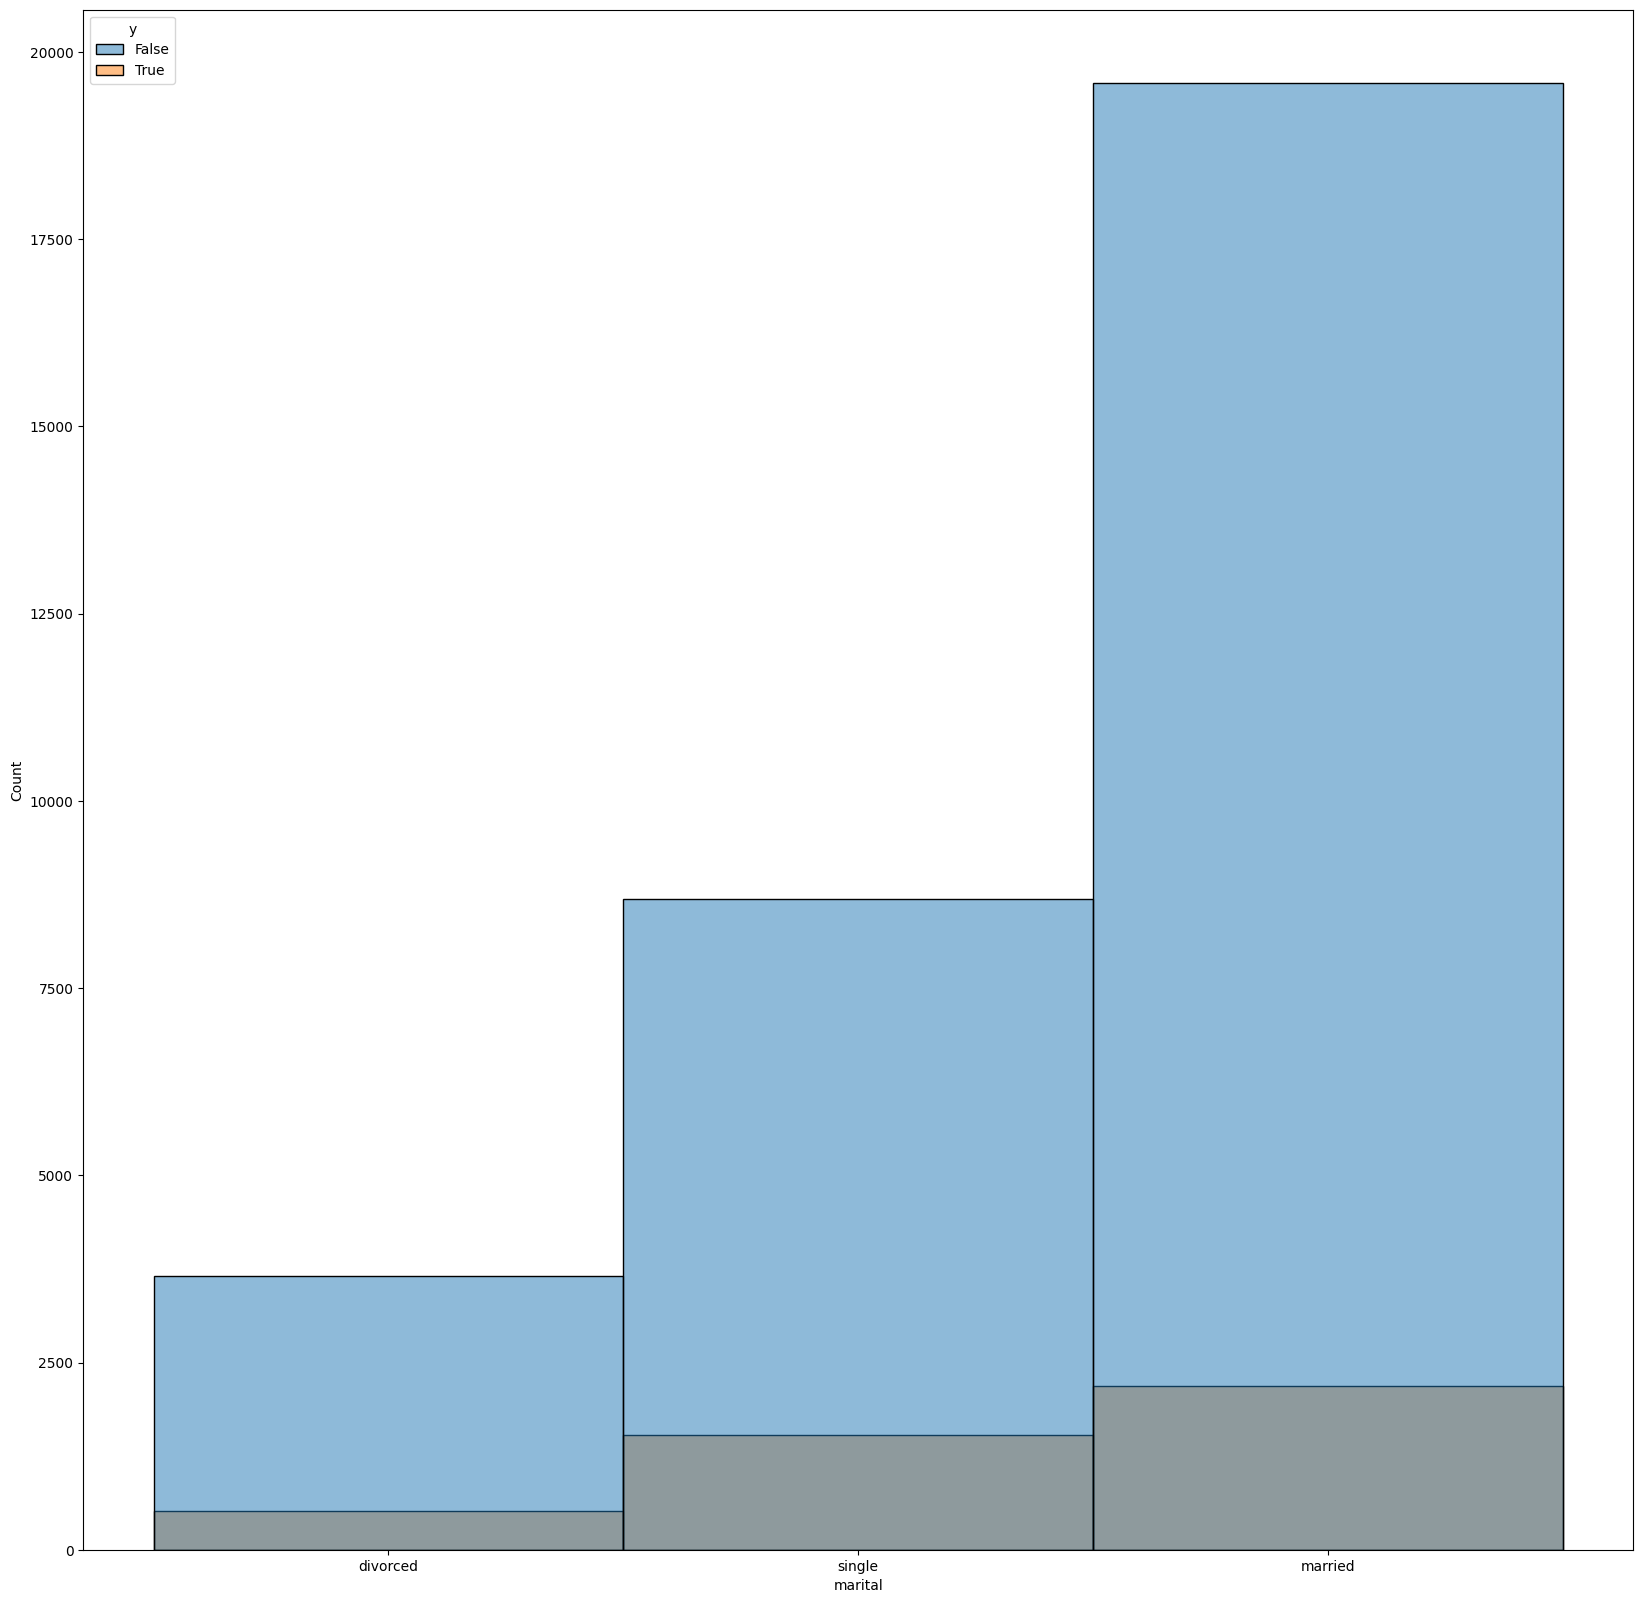

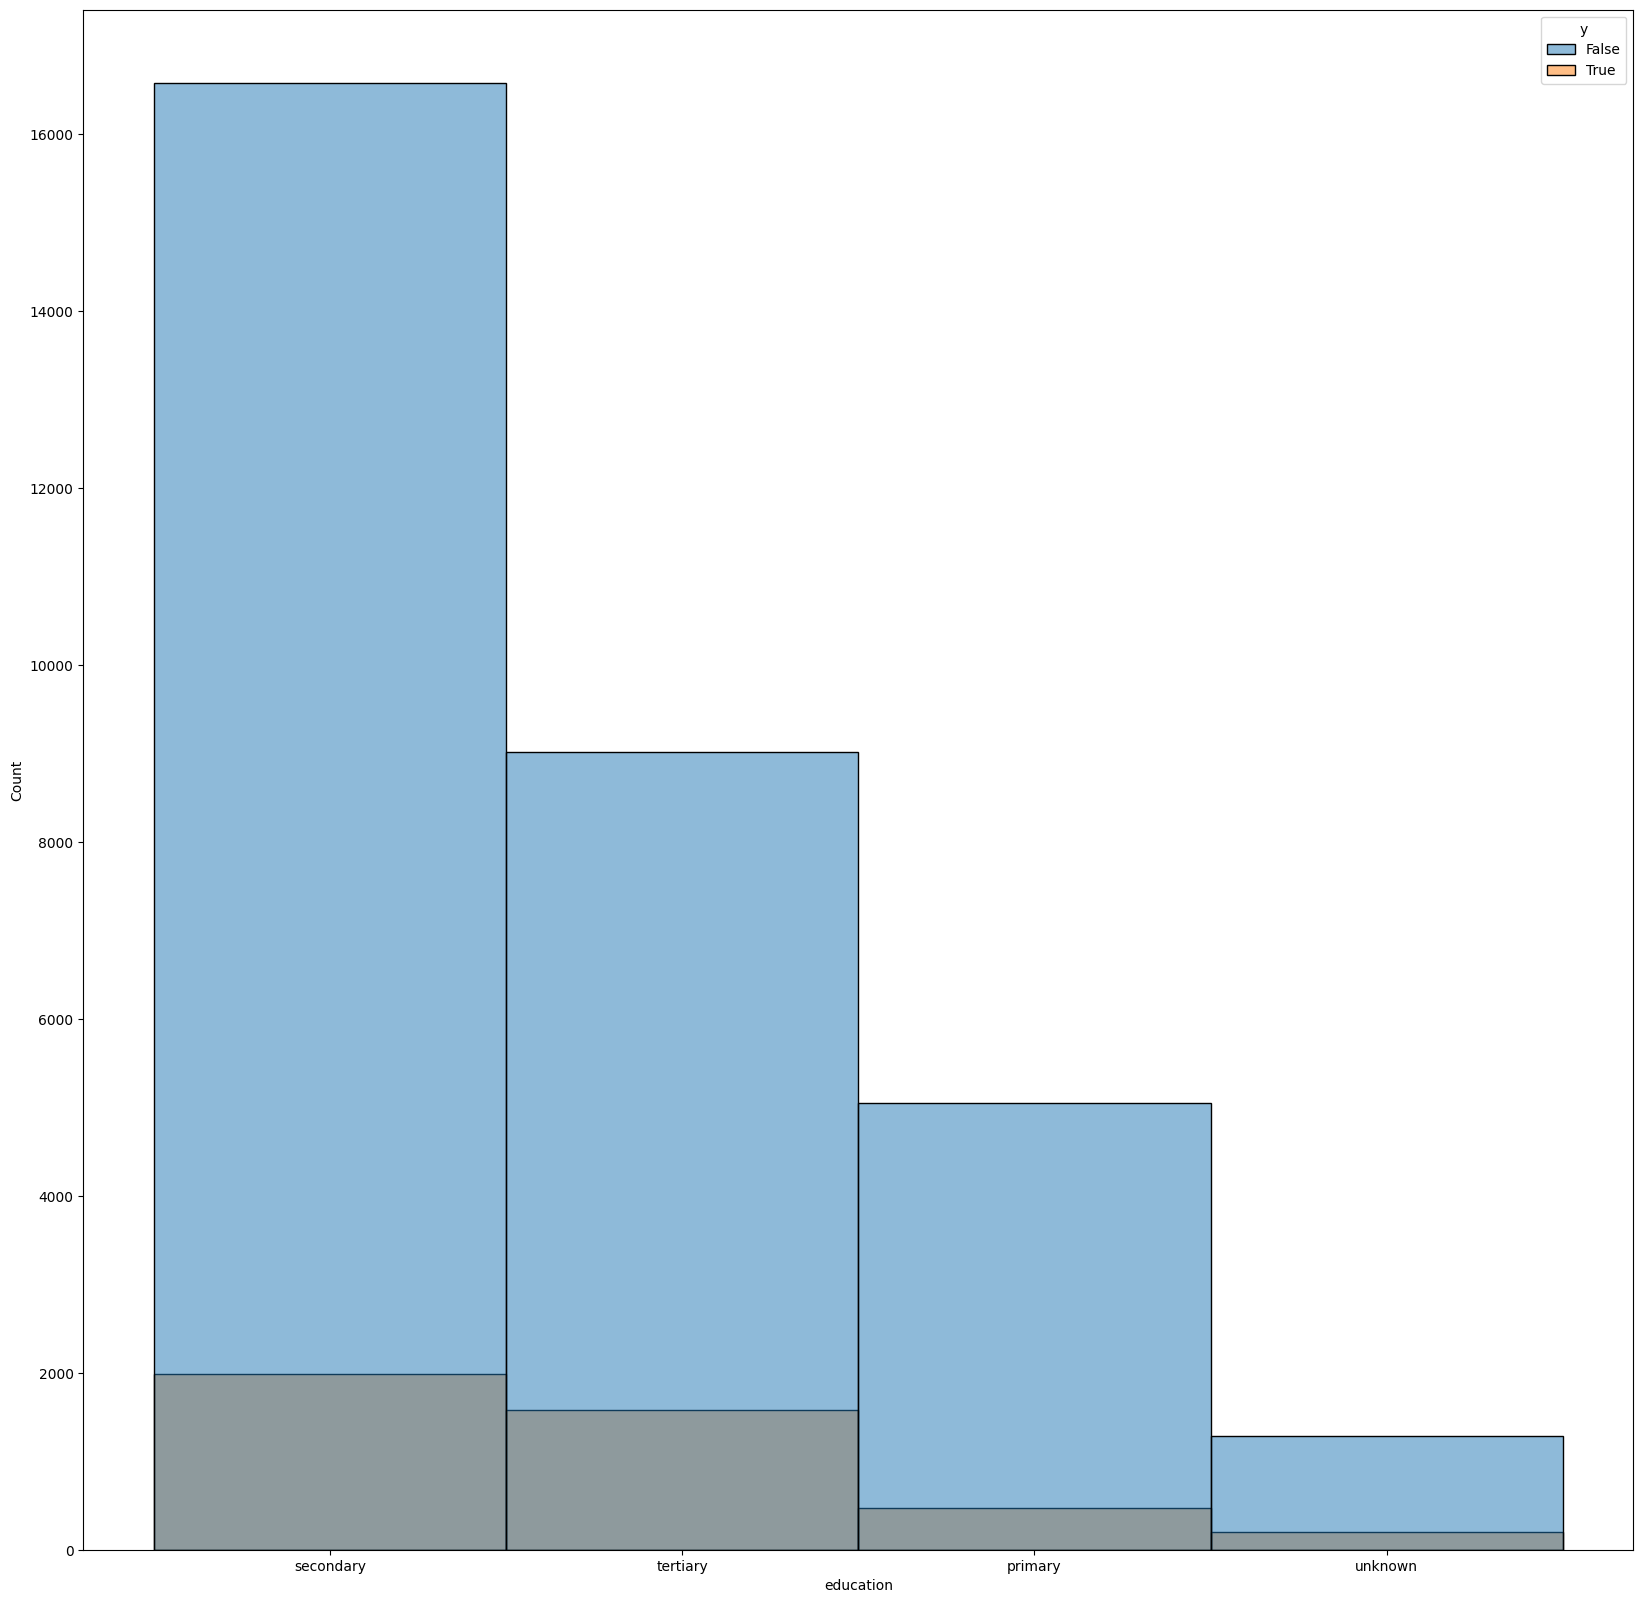

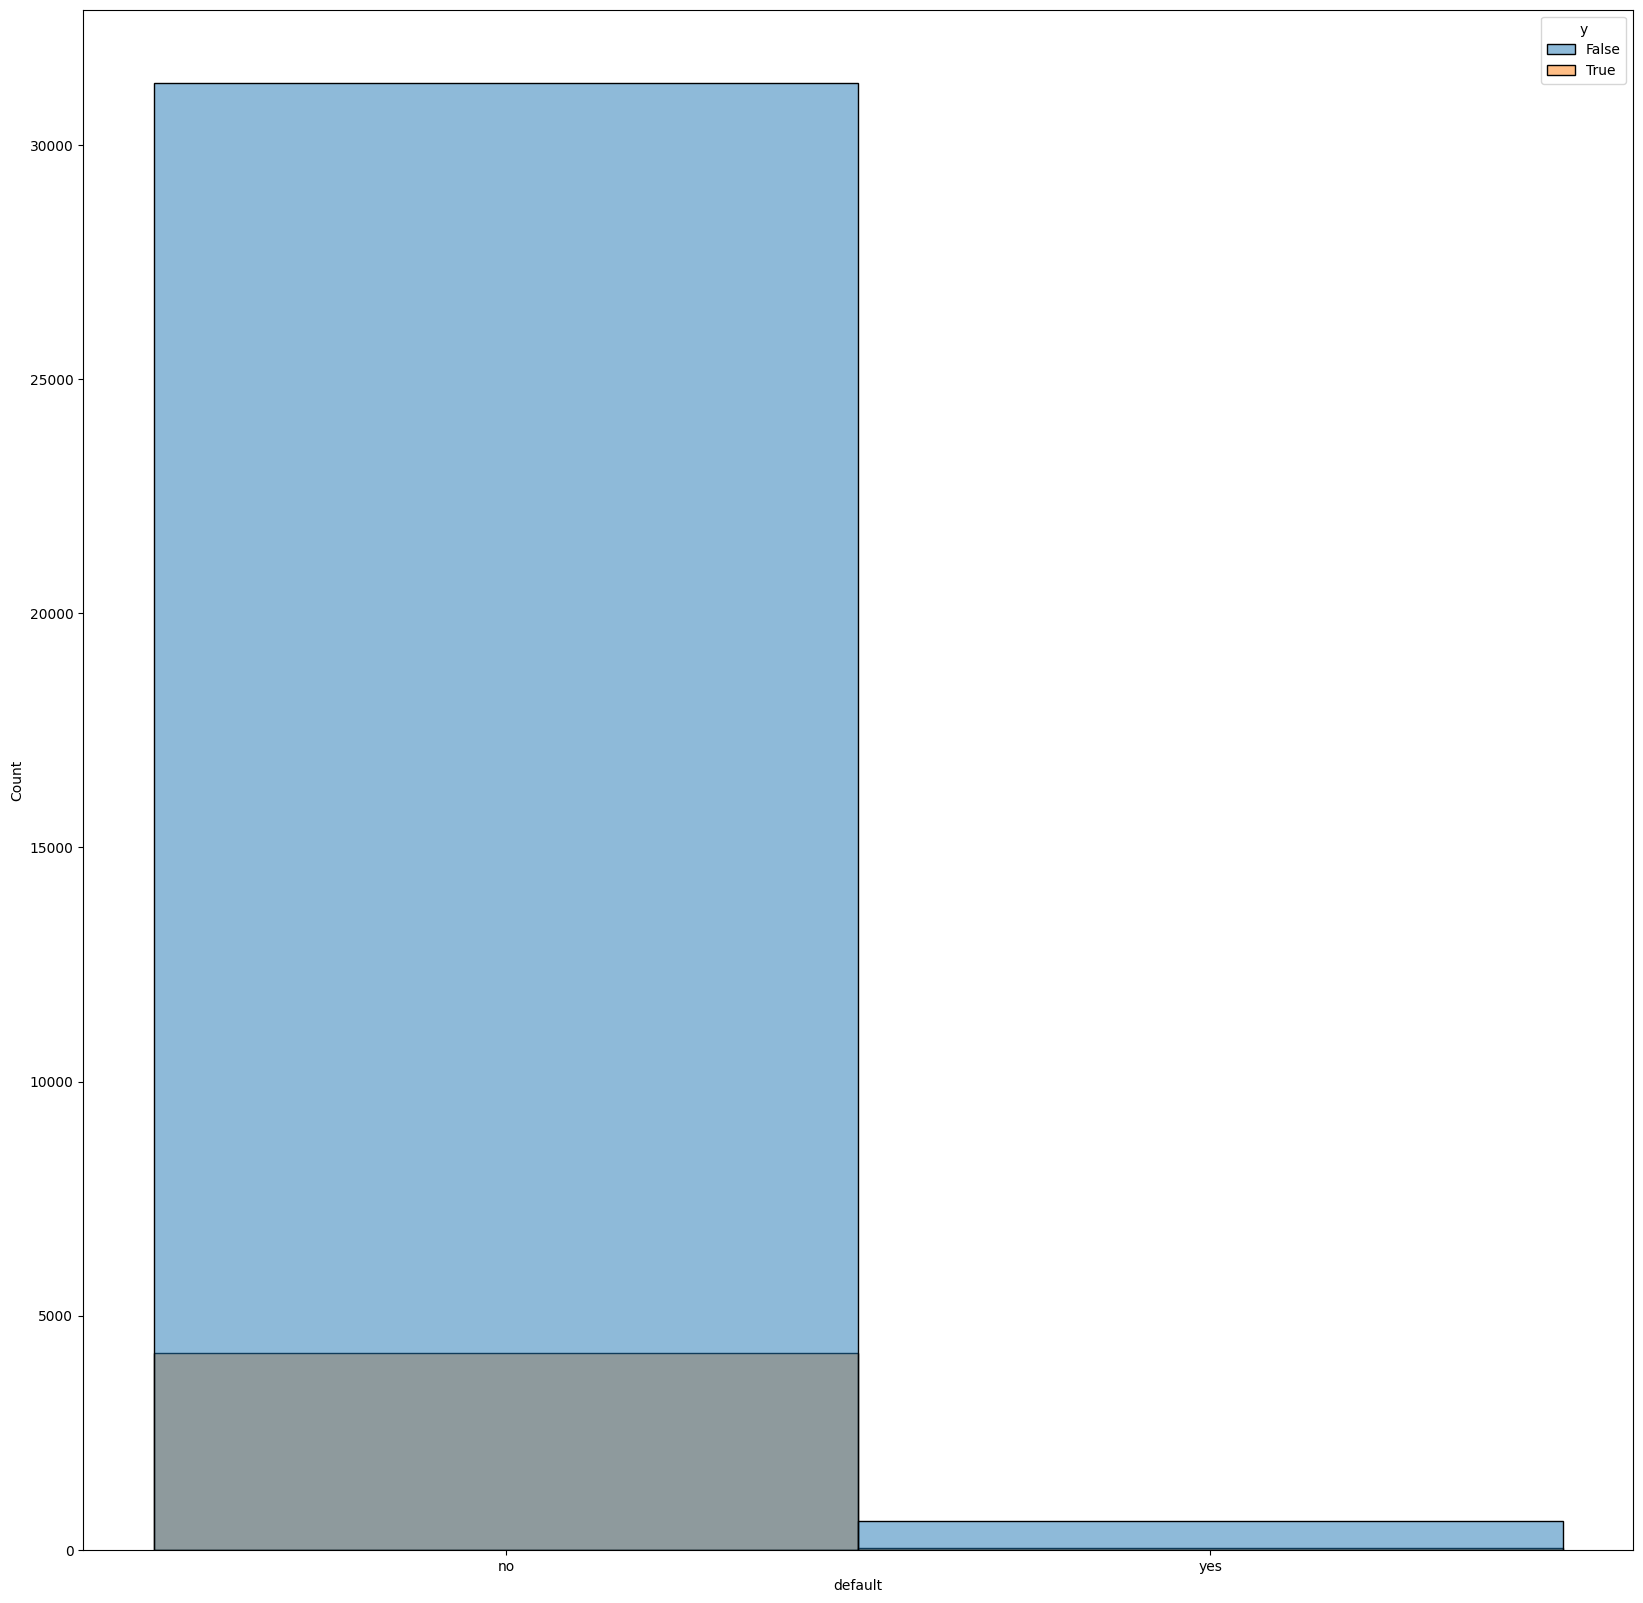

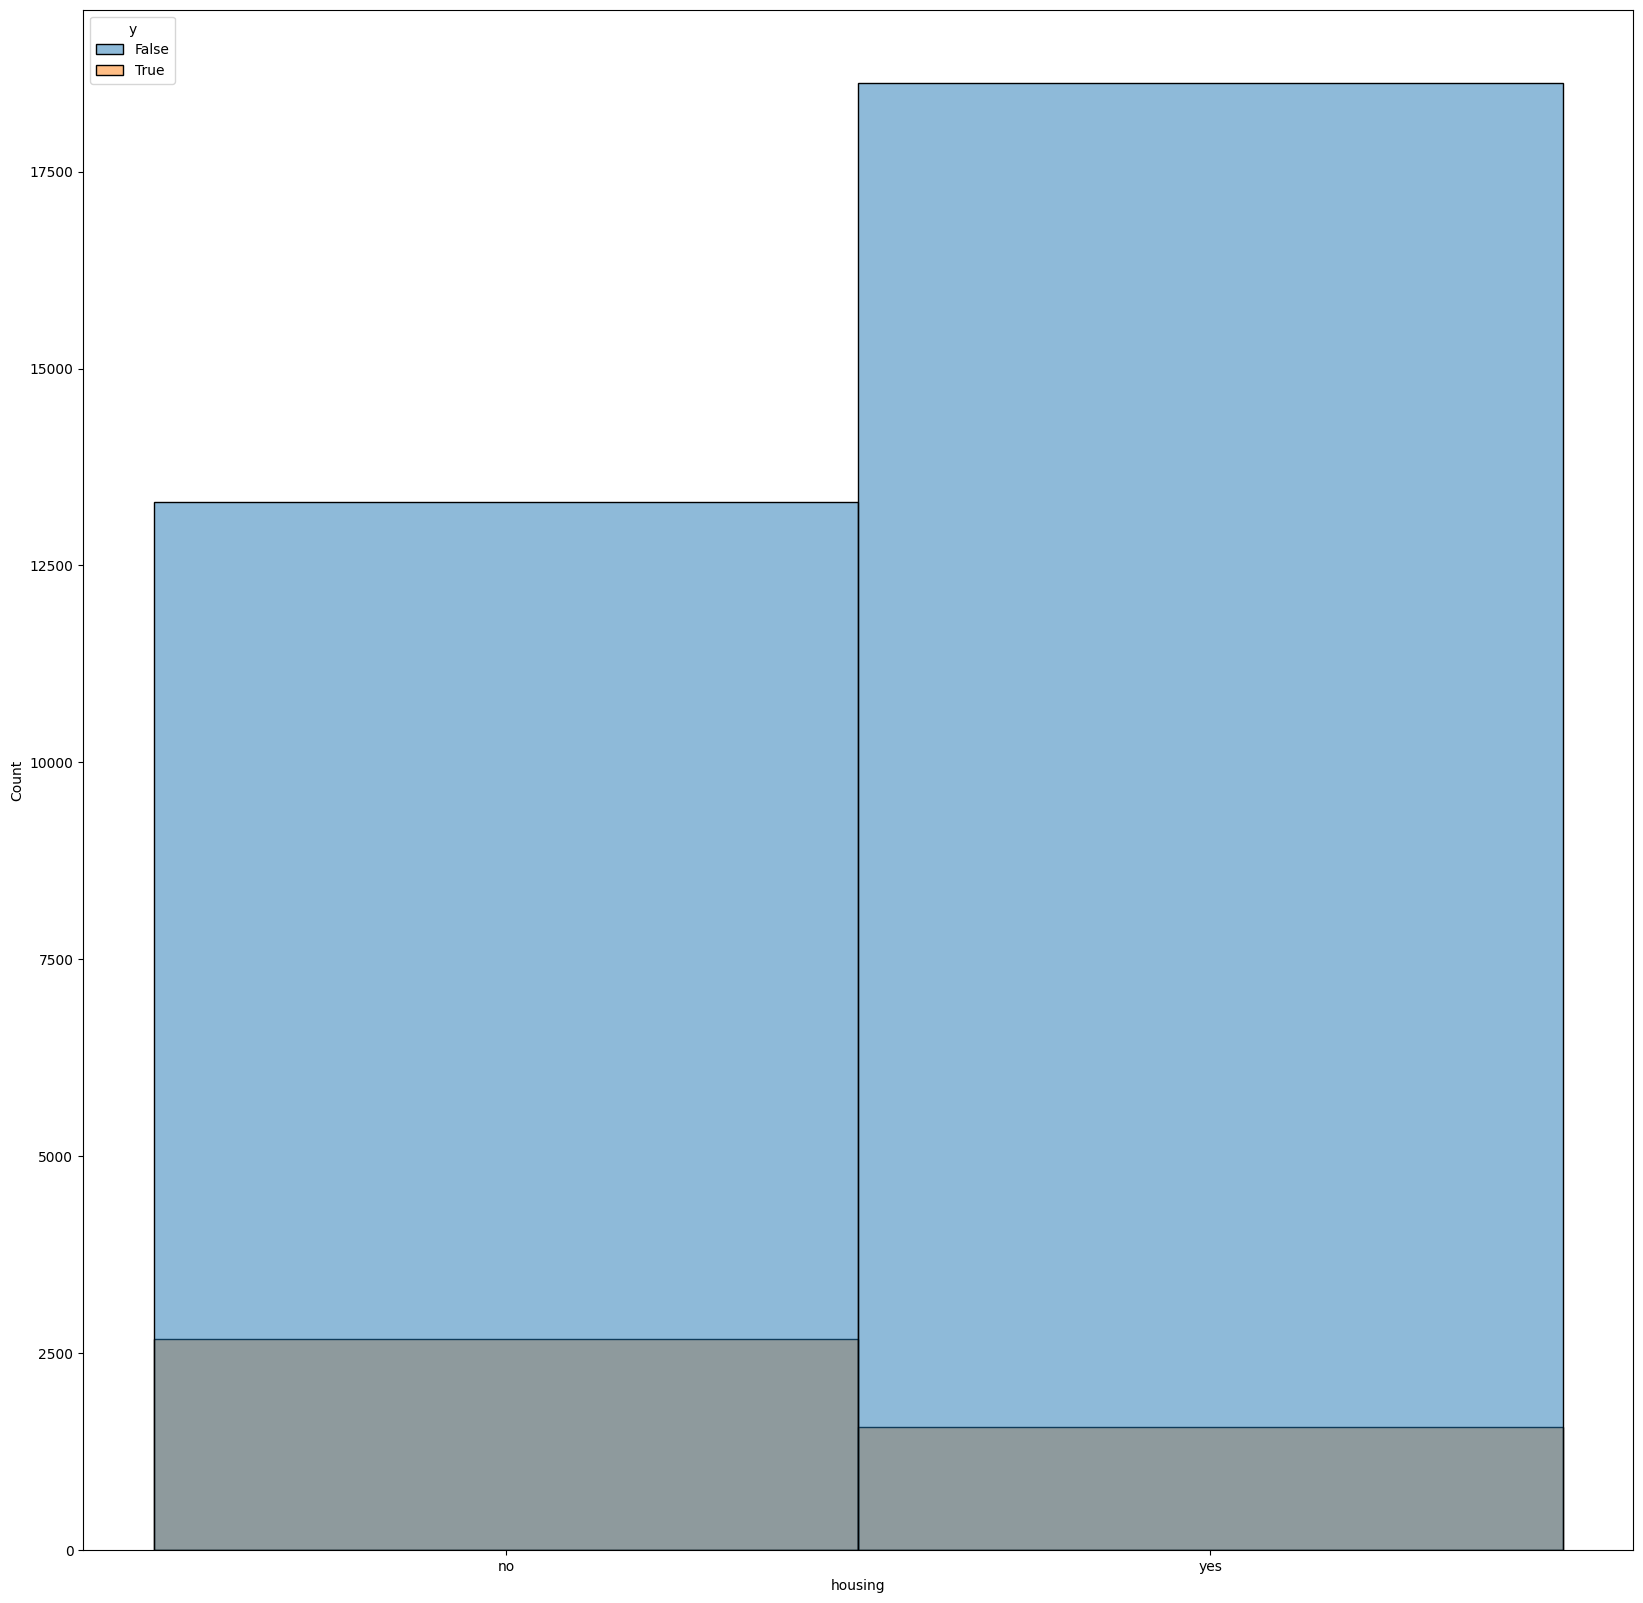

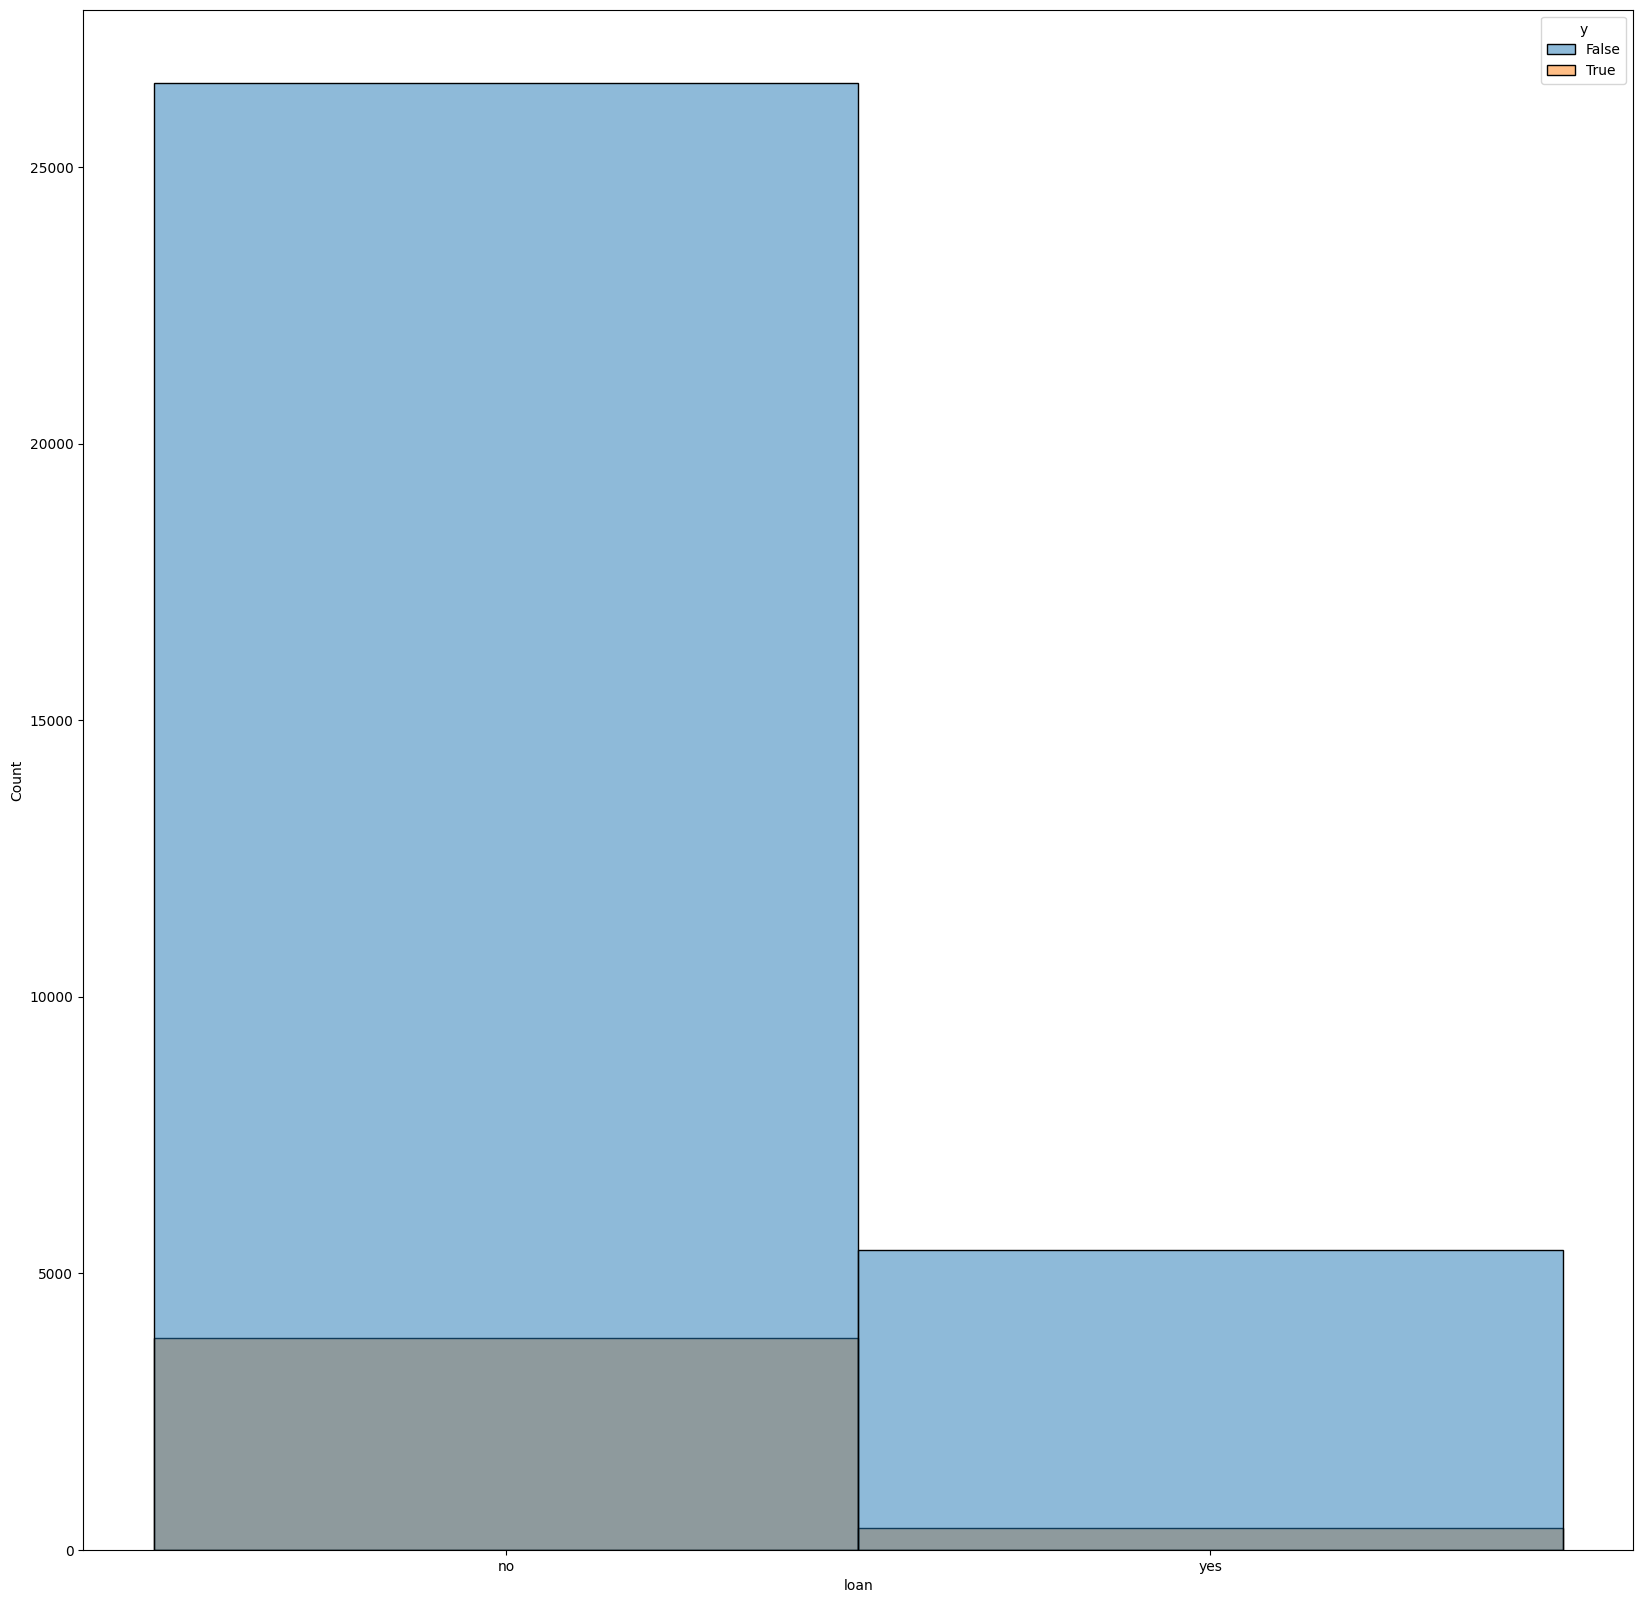

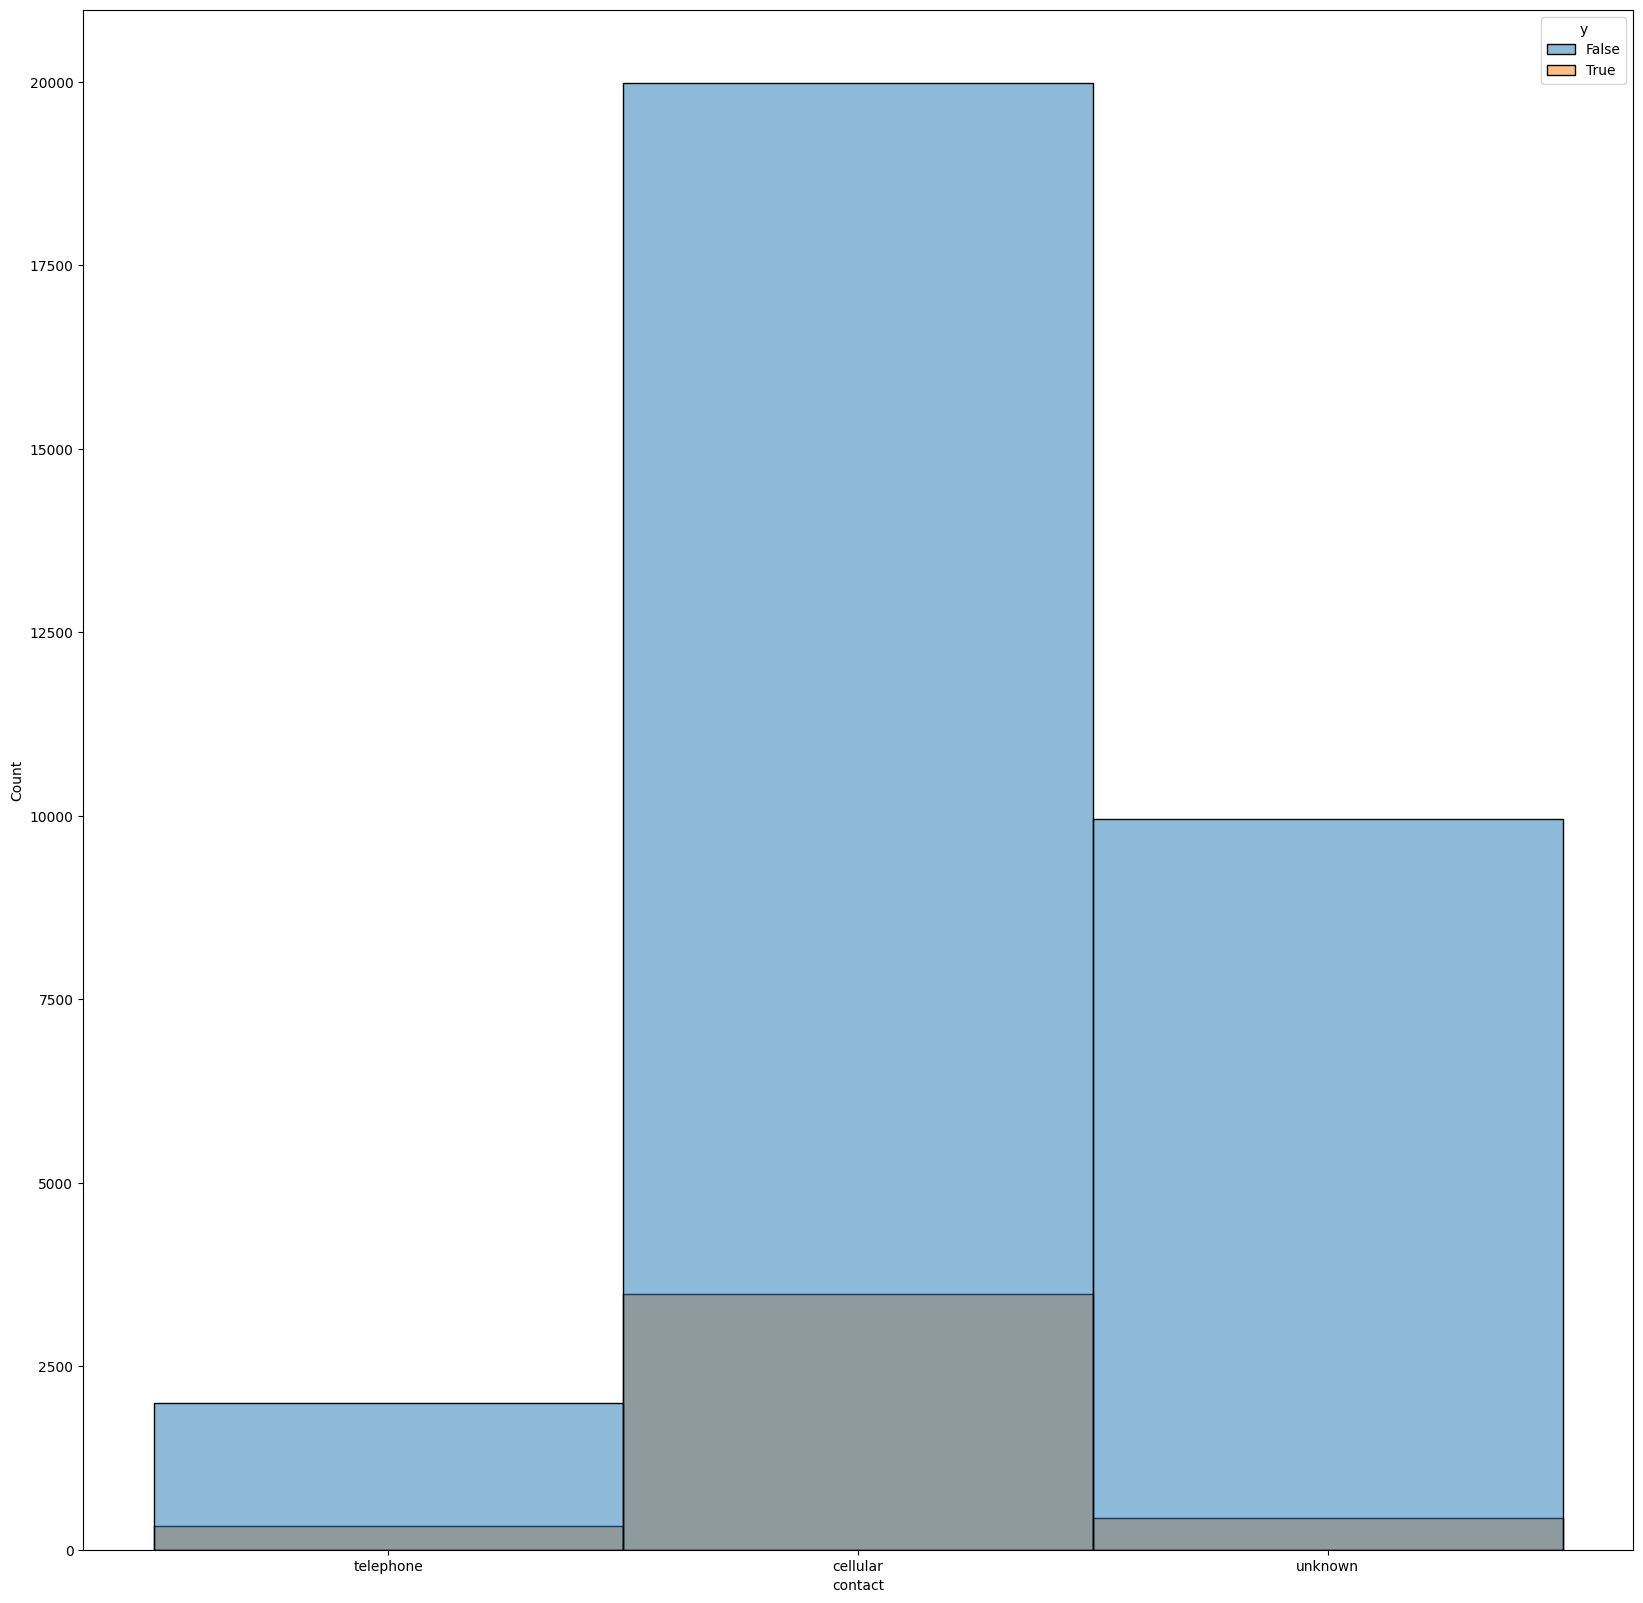

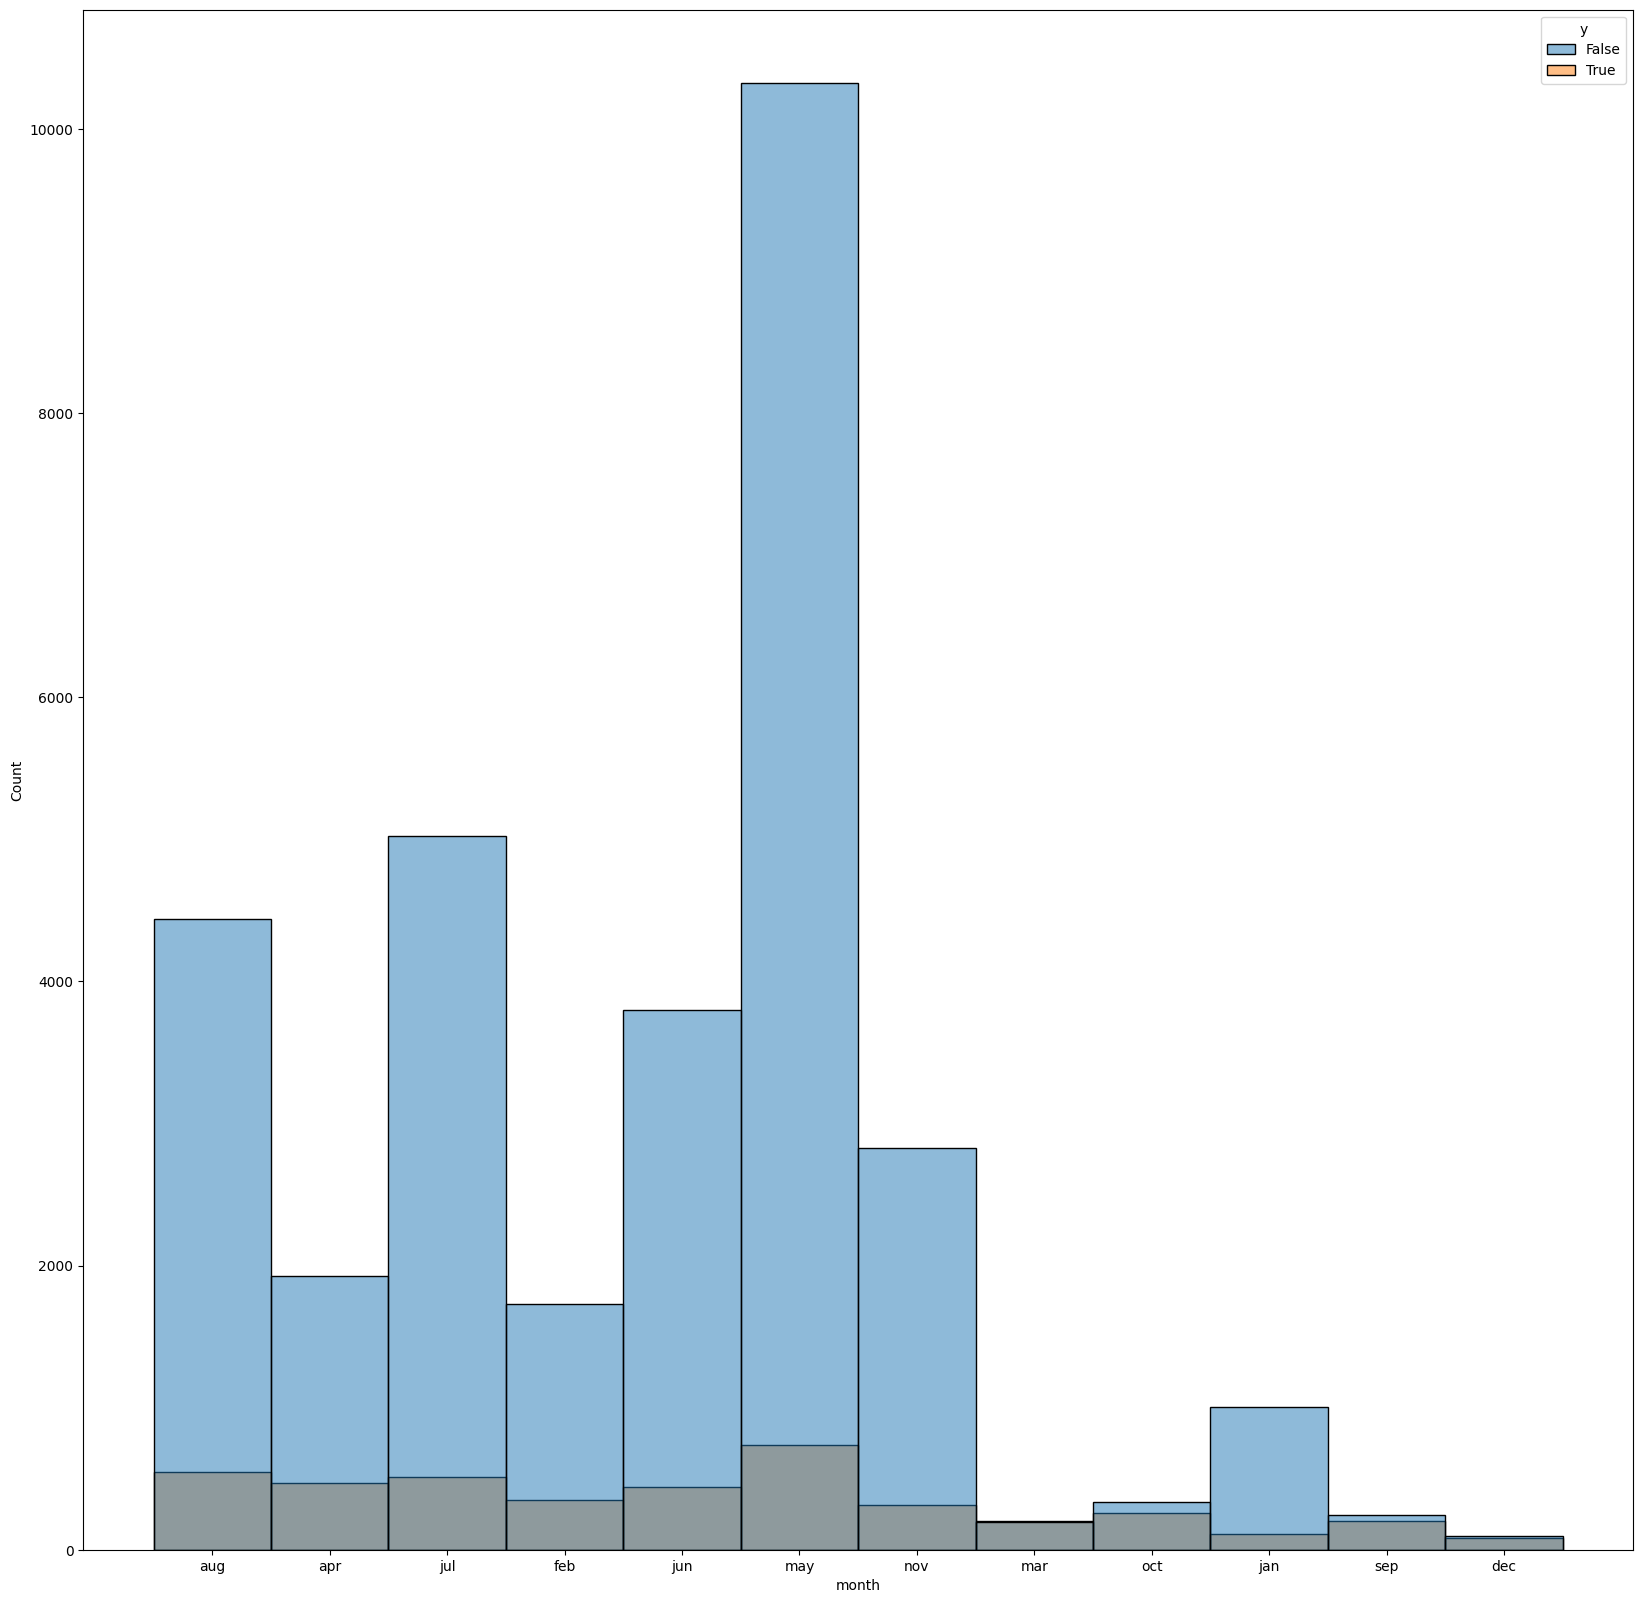

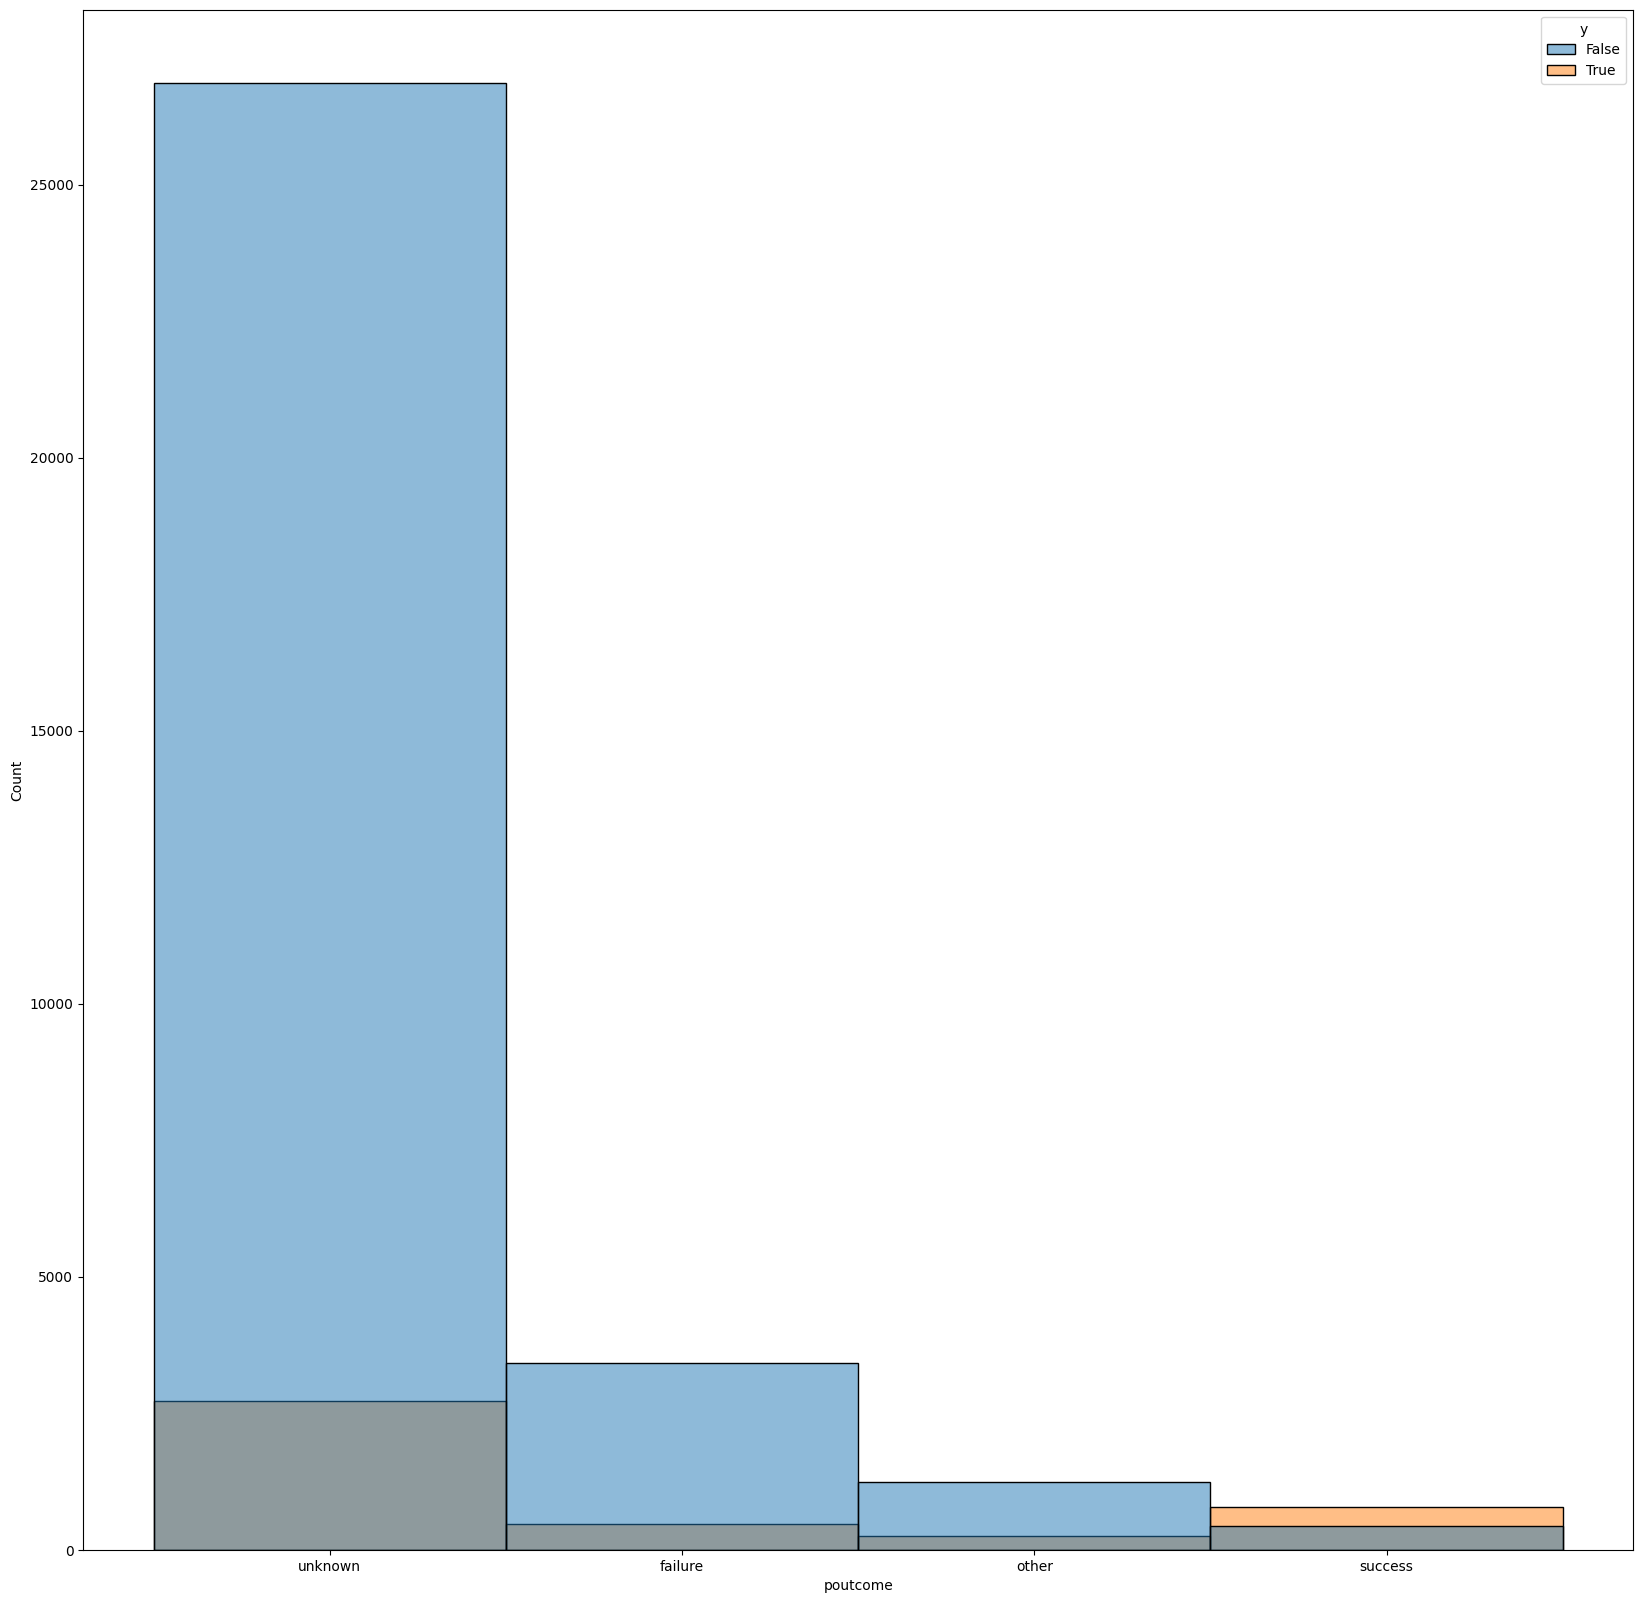

In [152]:
for col in col_cat:
    fig = plt.figure(figsize=(20, 20))
    sns.histplot(data=train, x=col, hue=target);

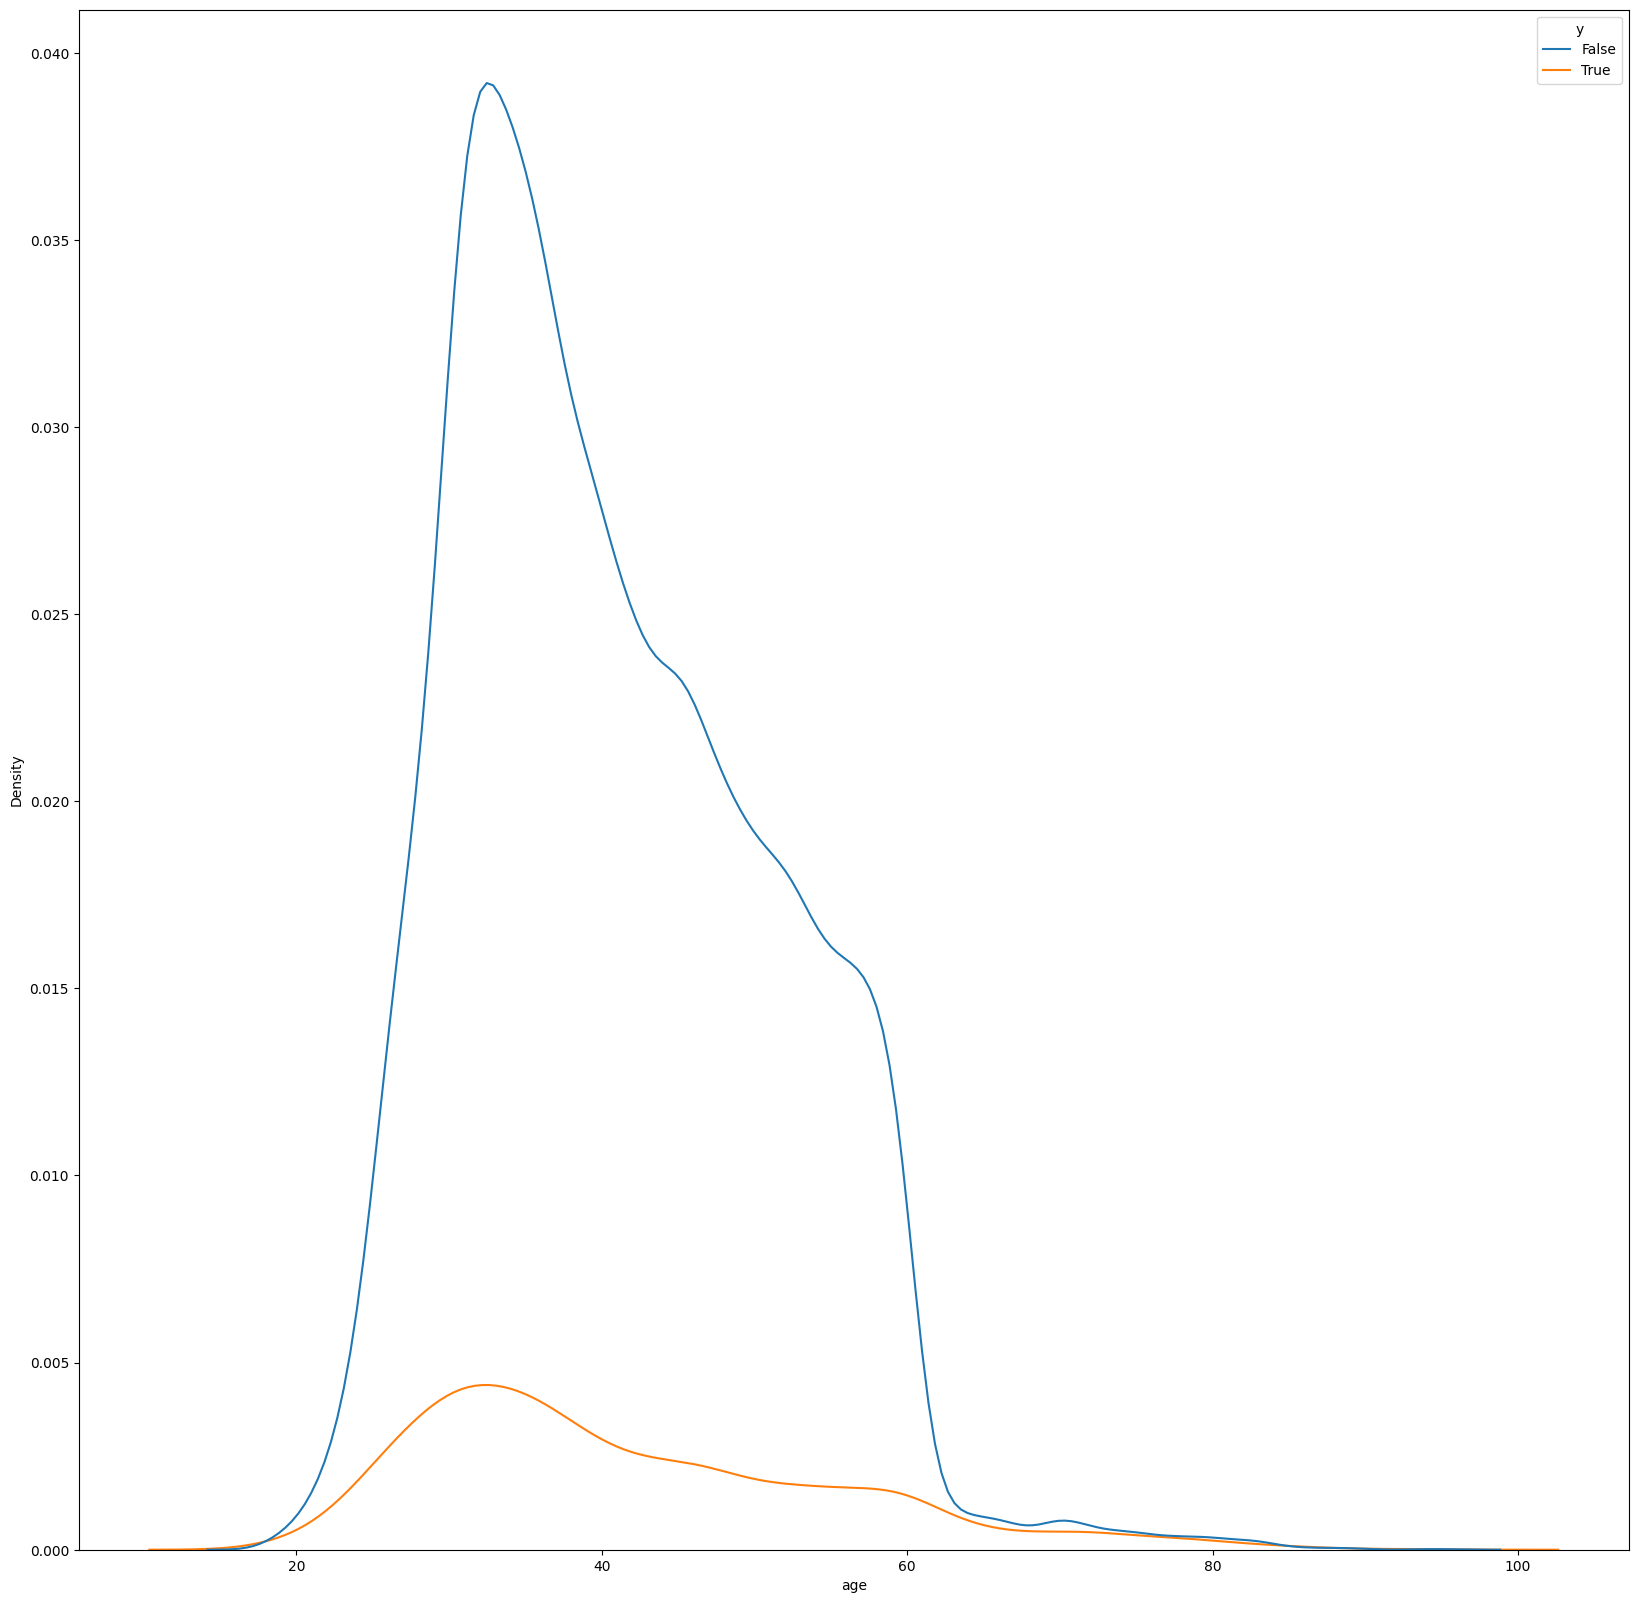

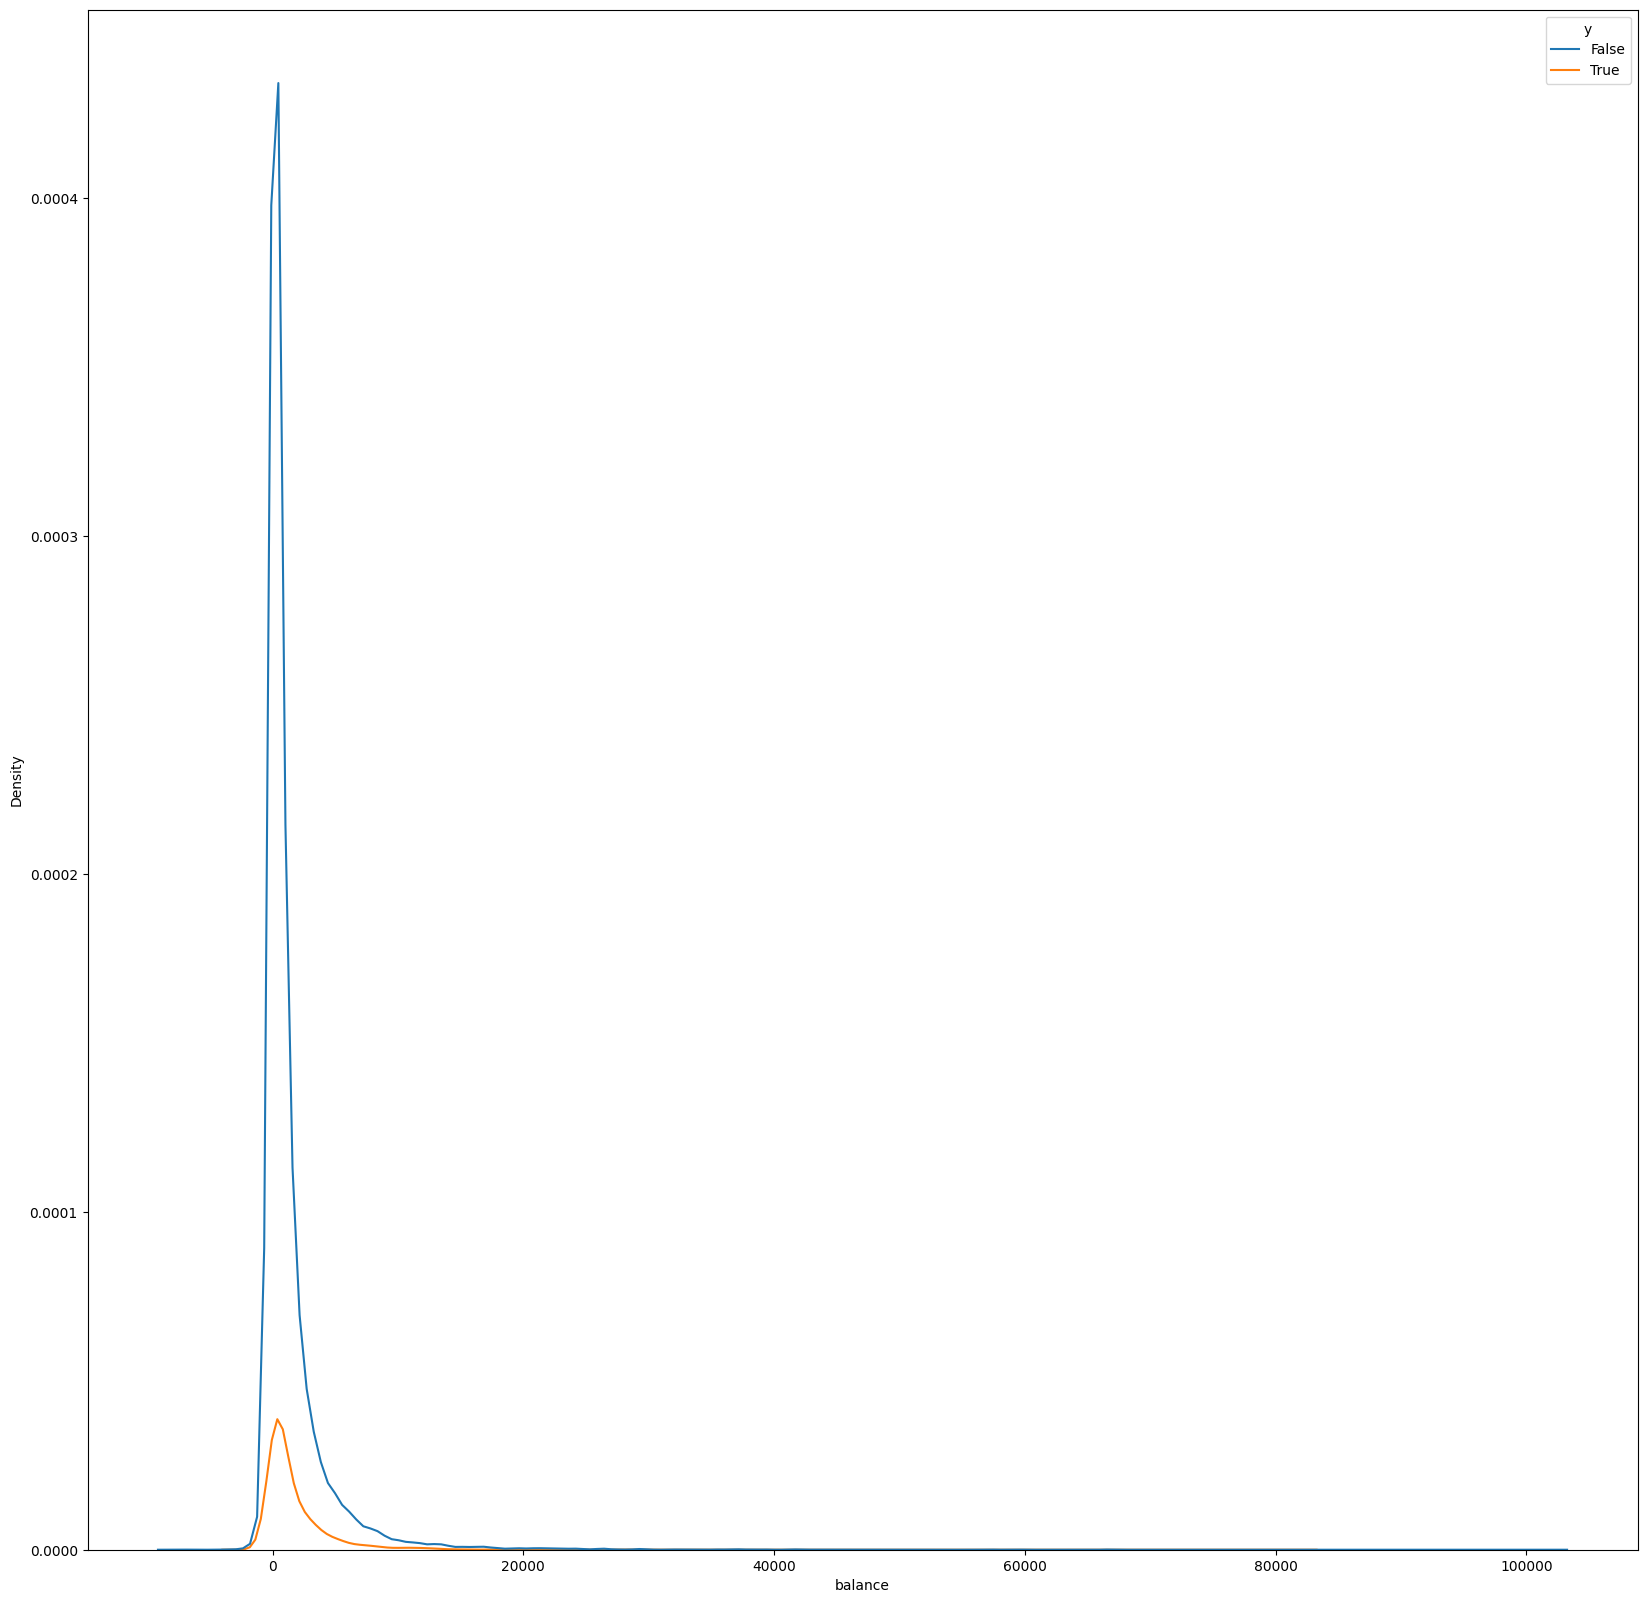

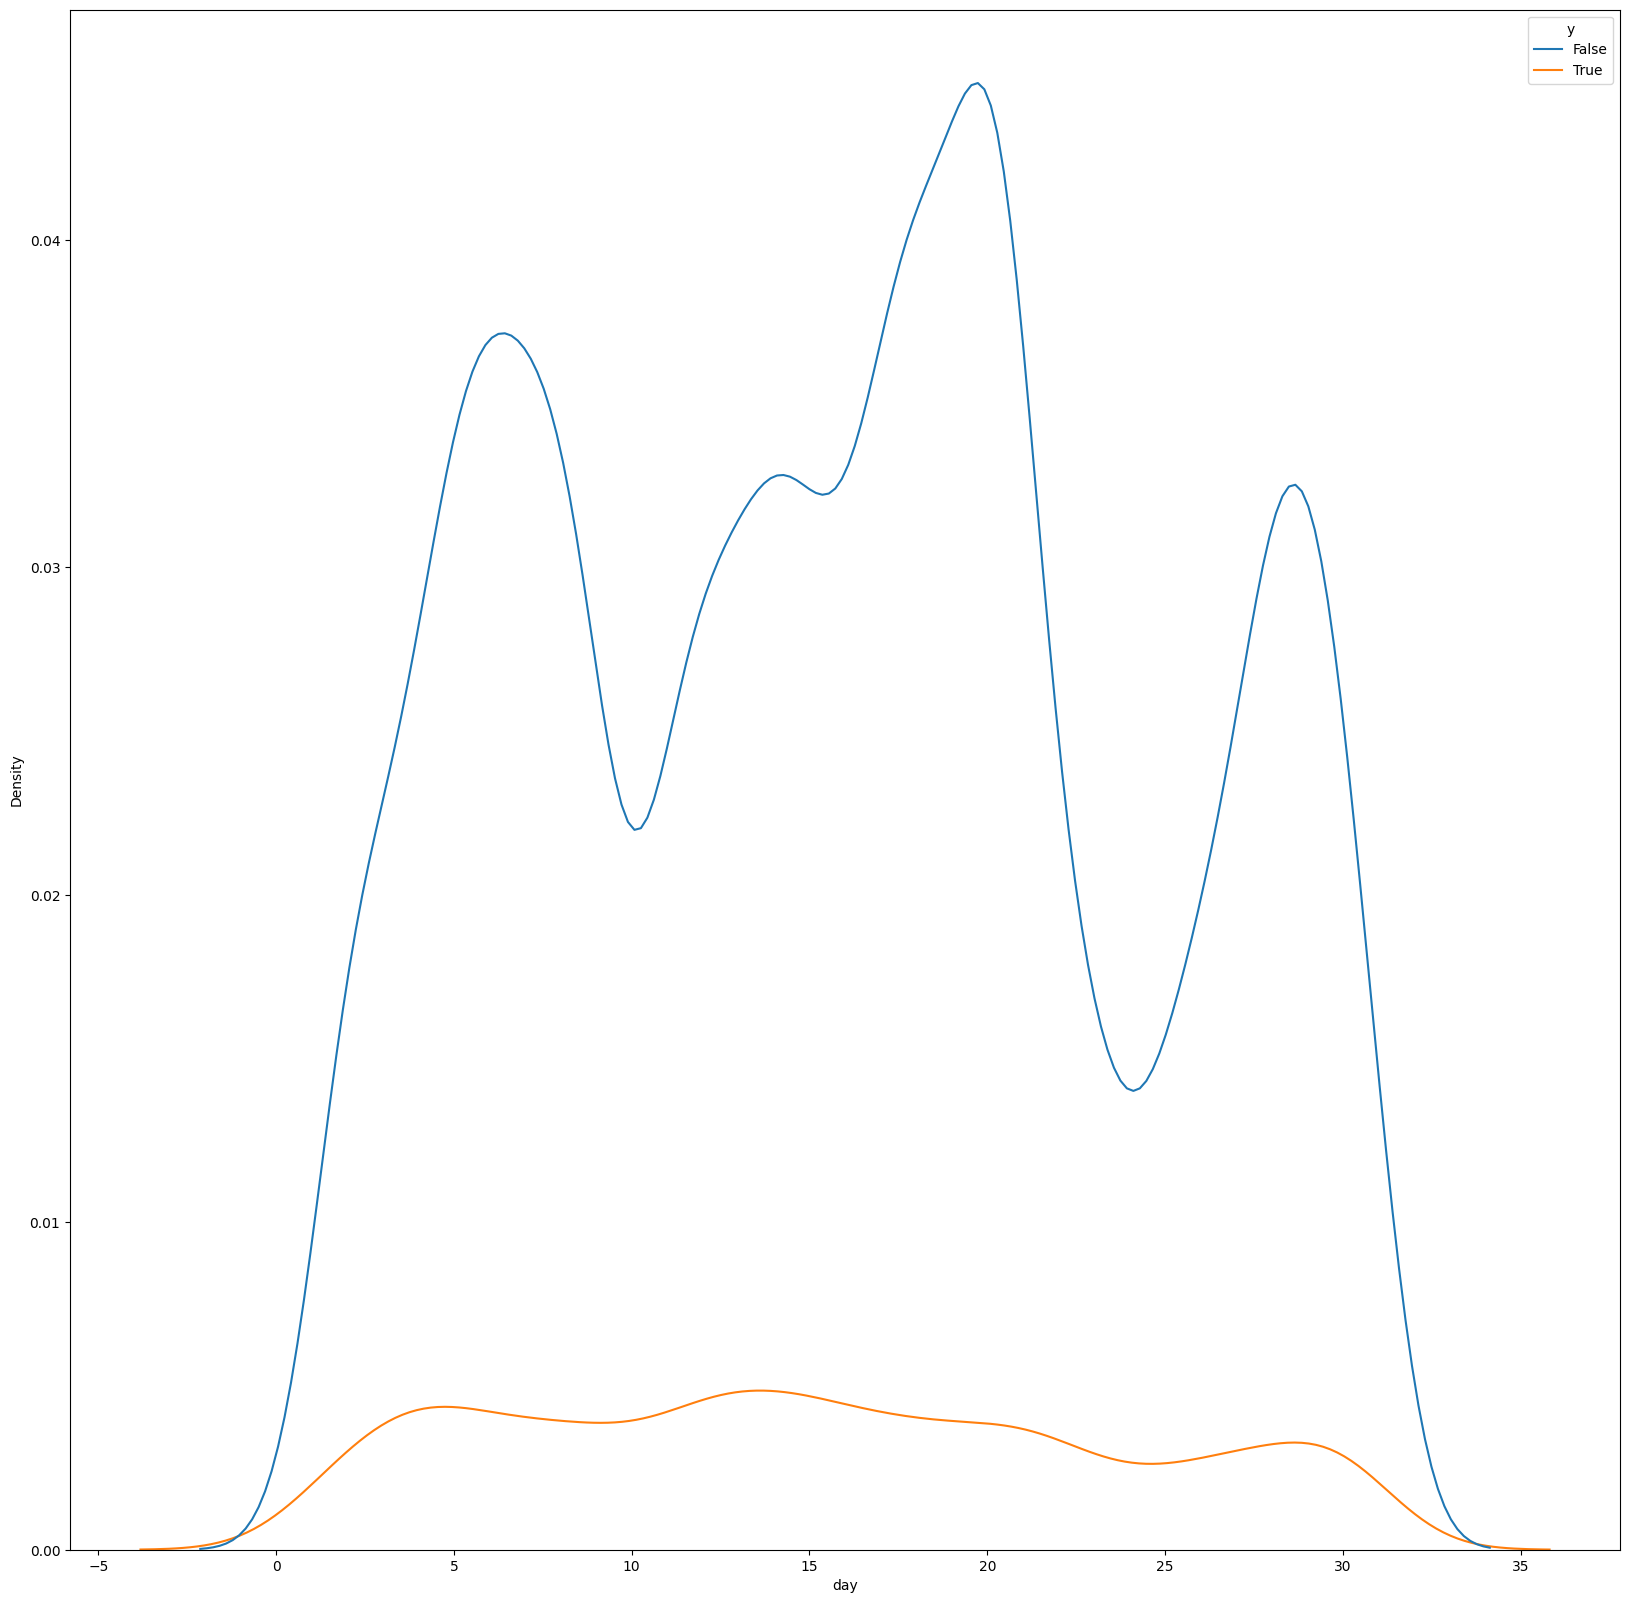

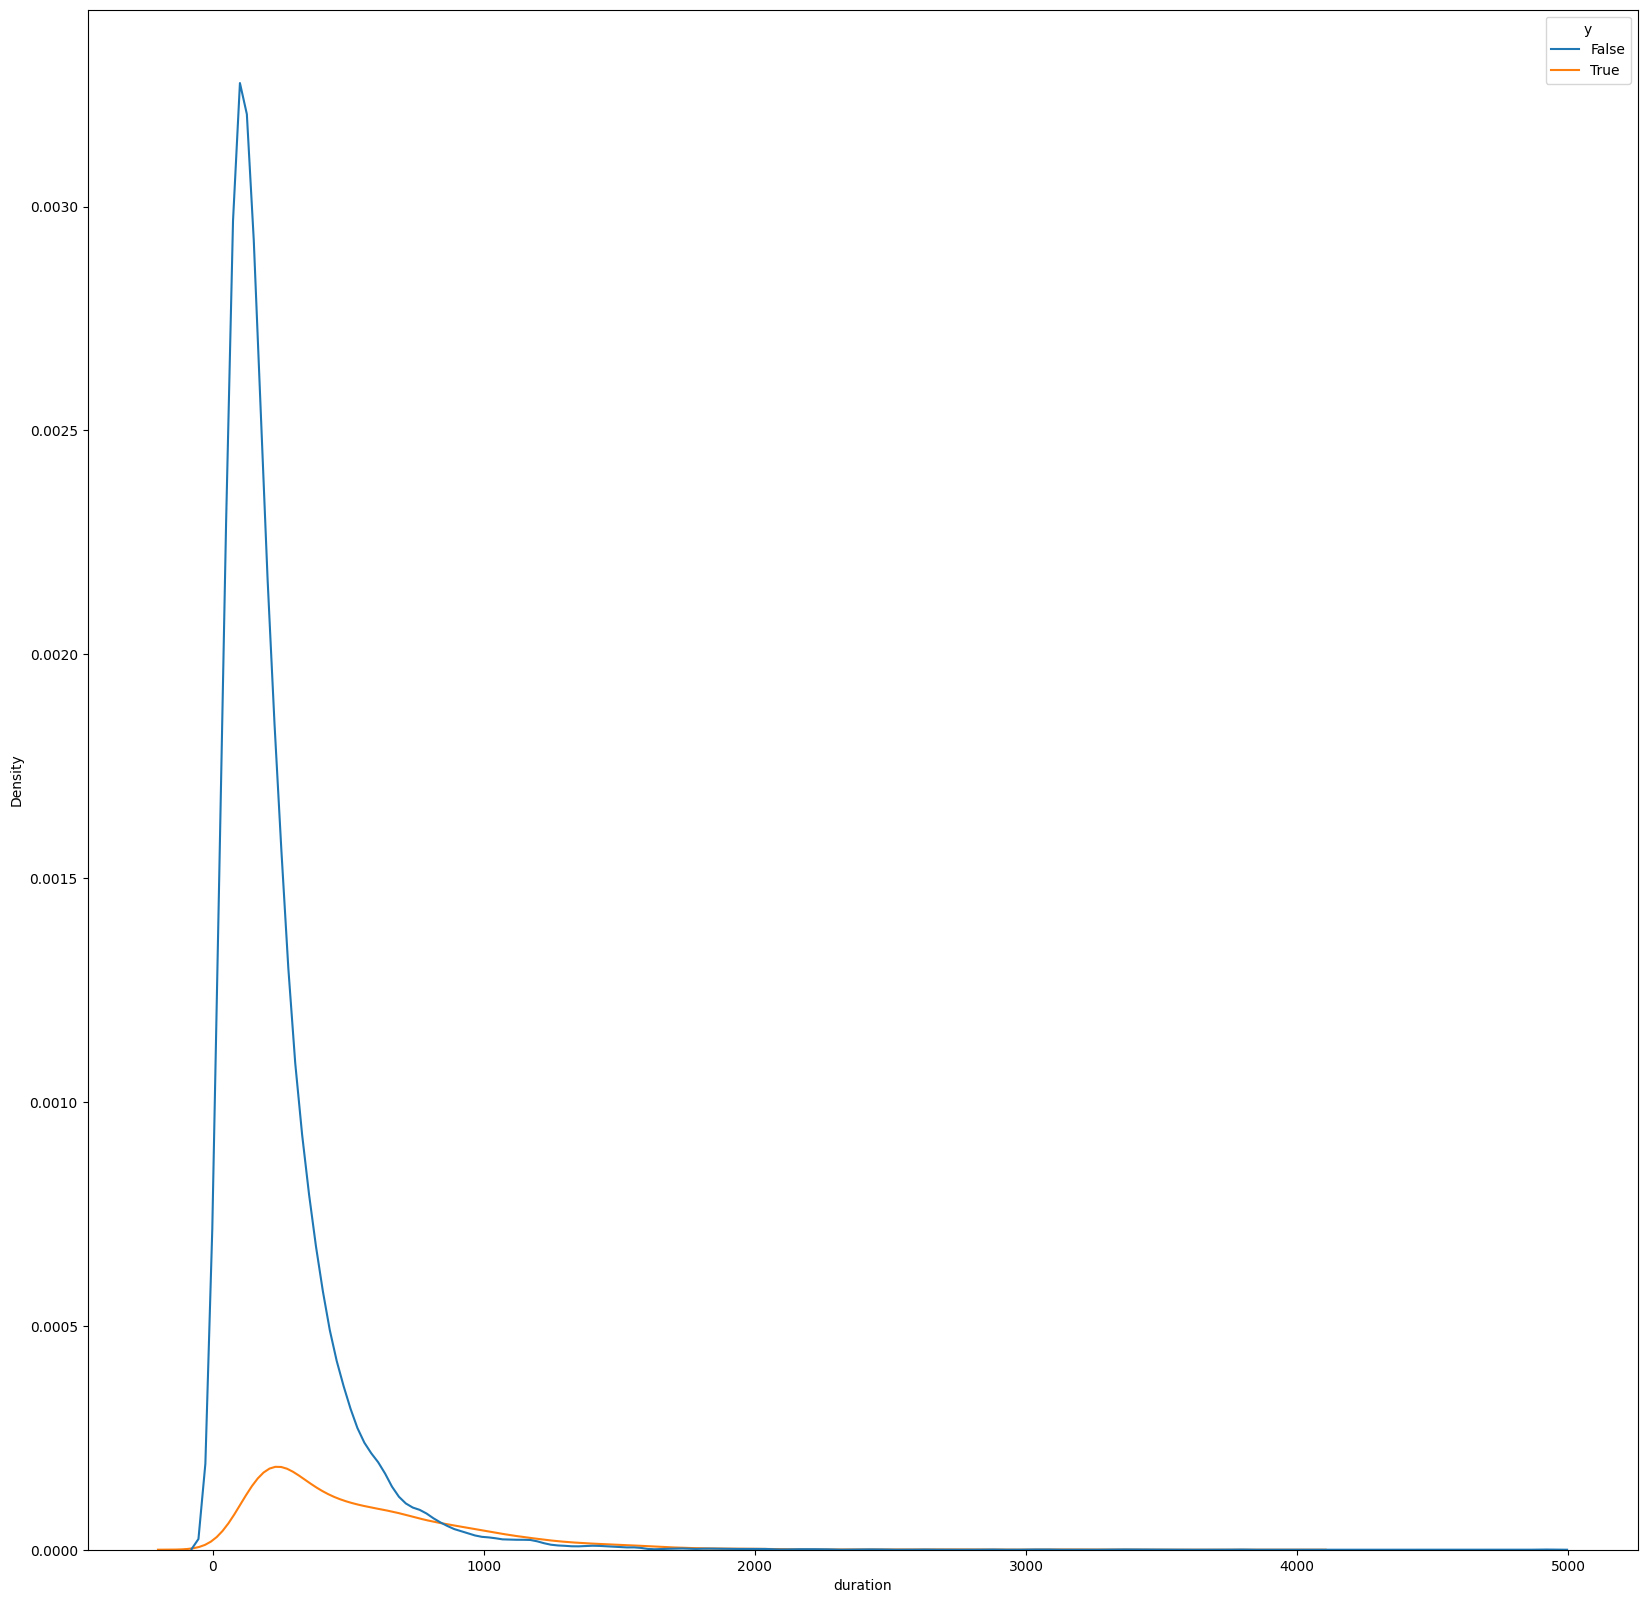

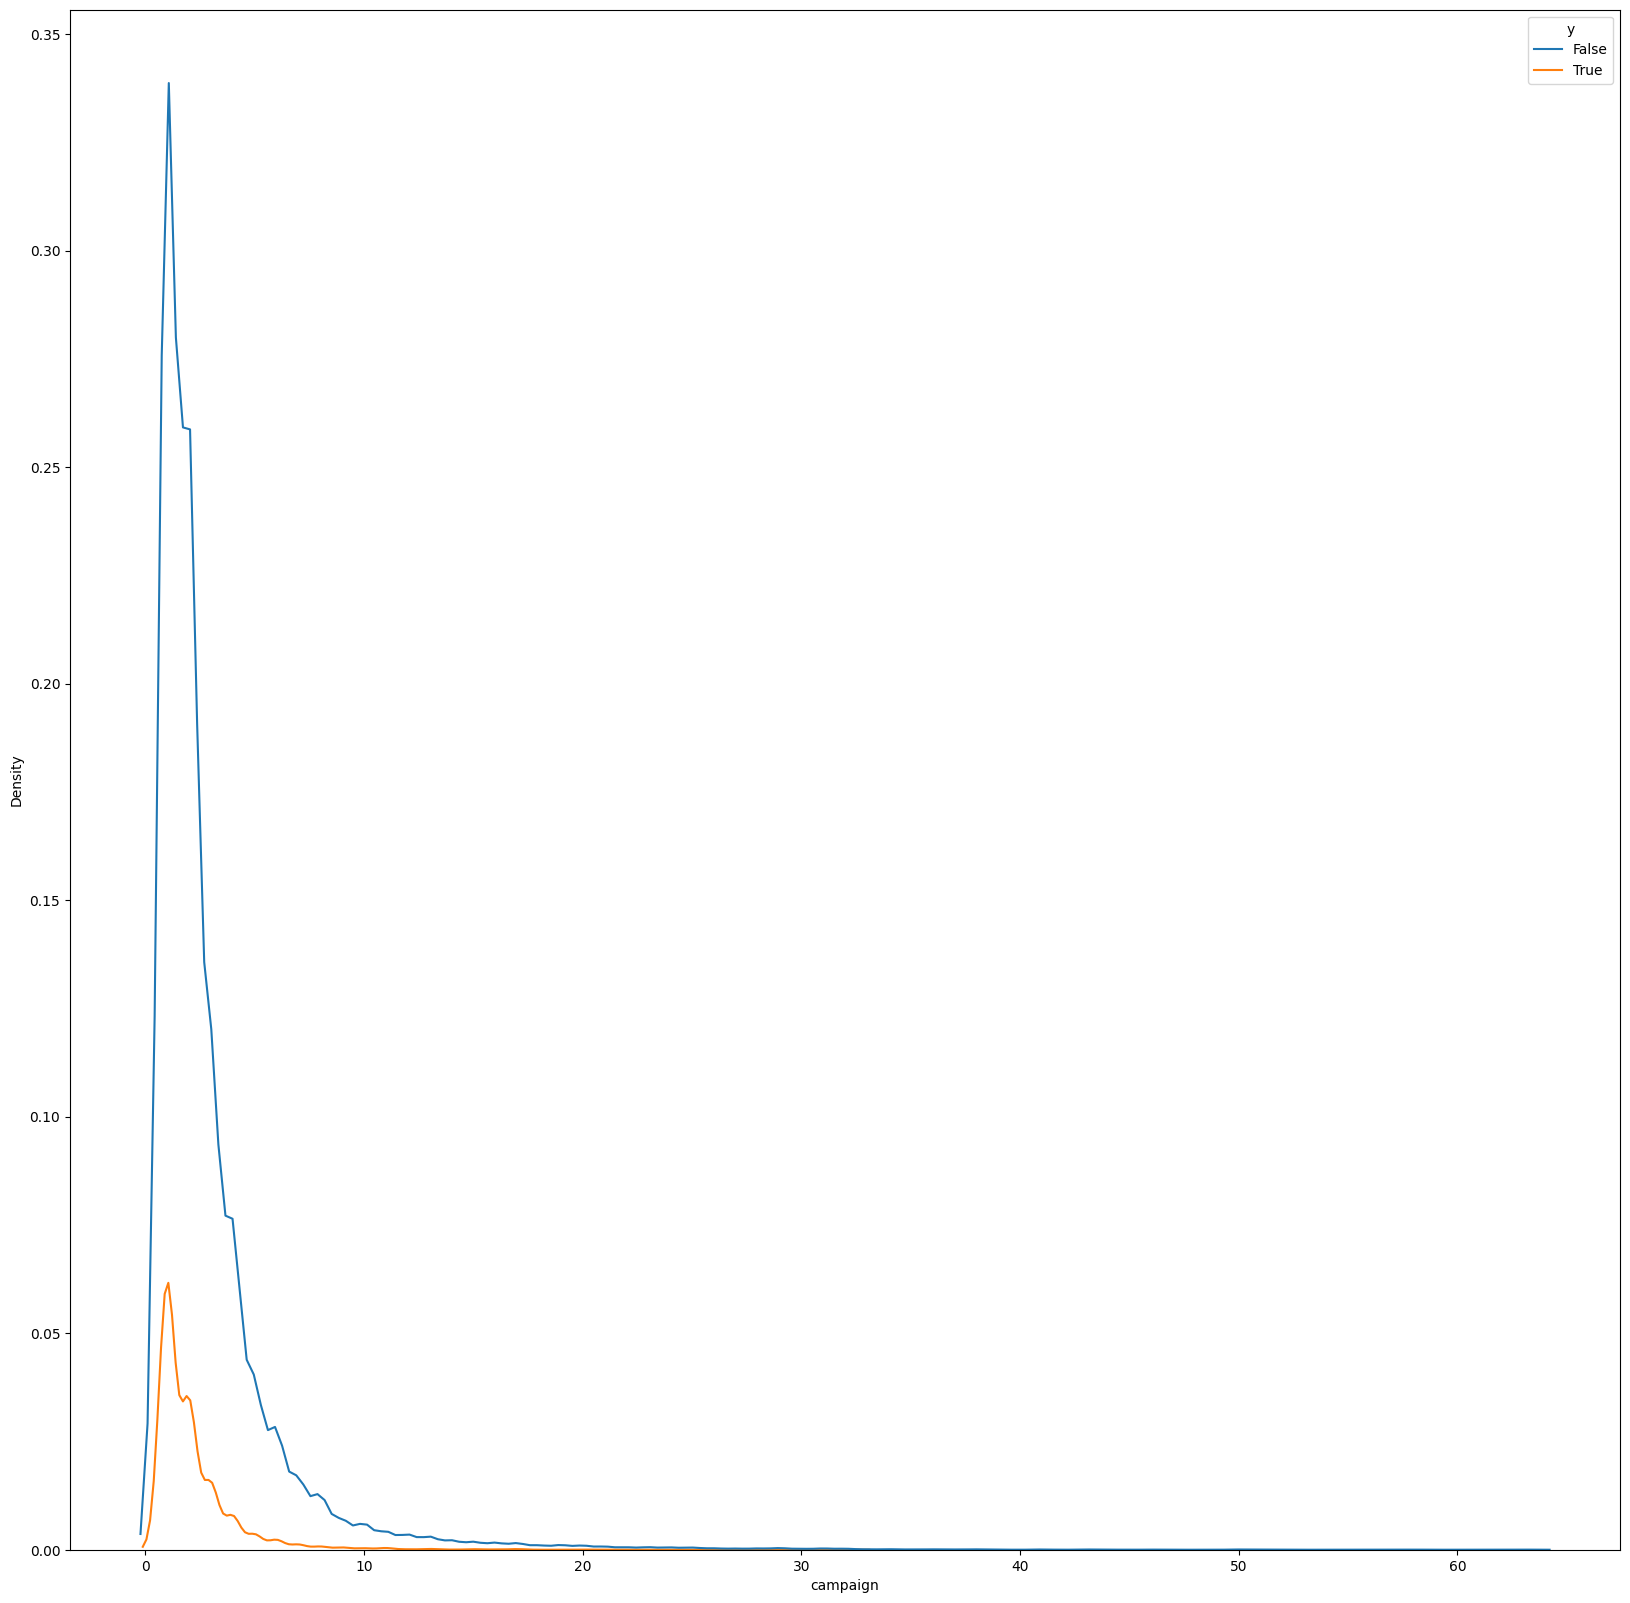

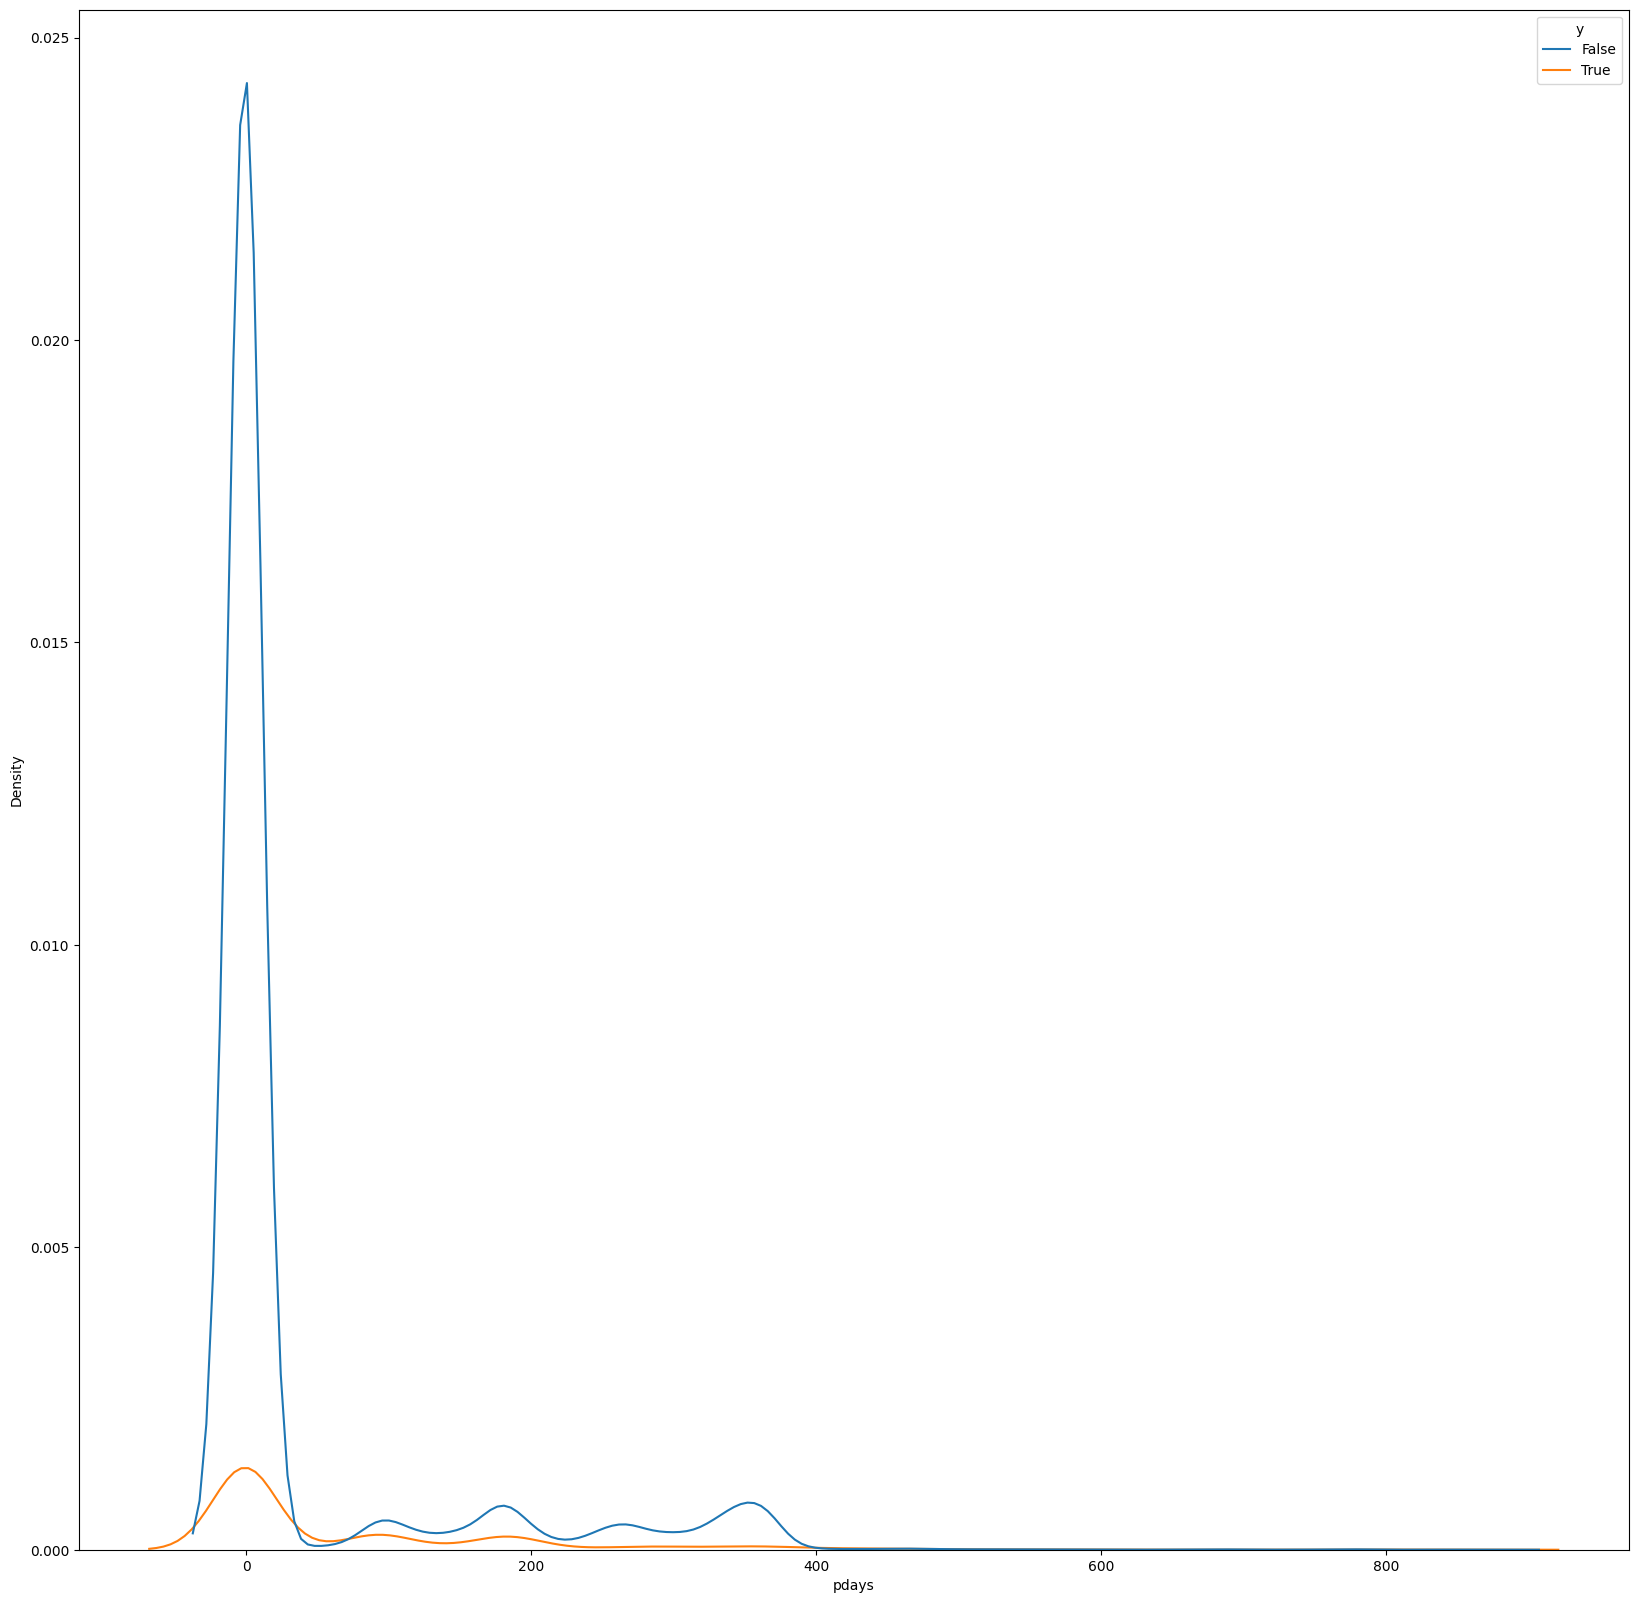

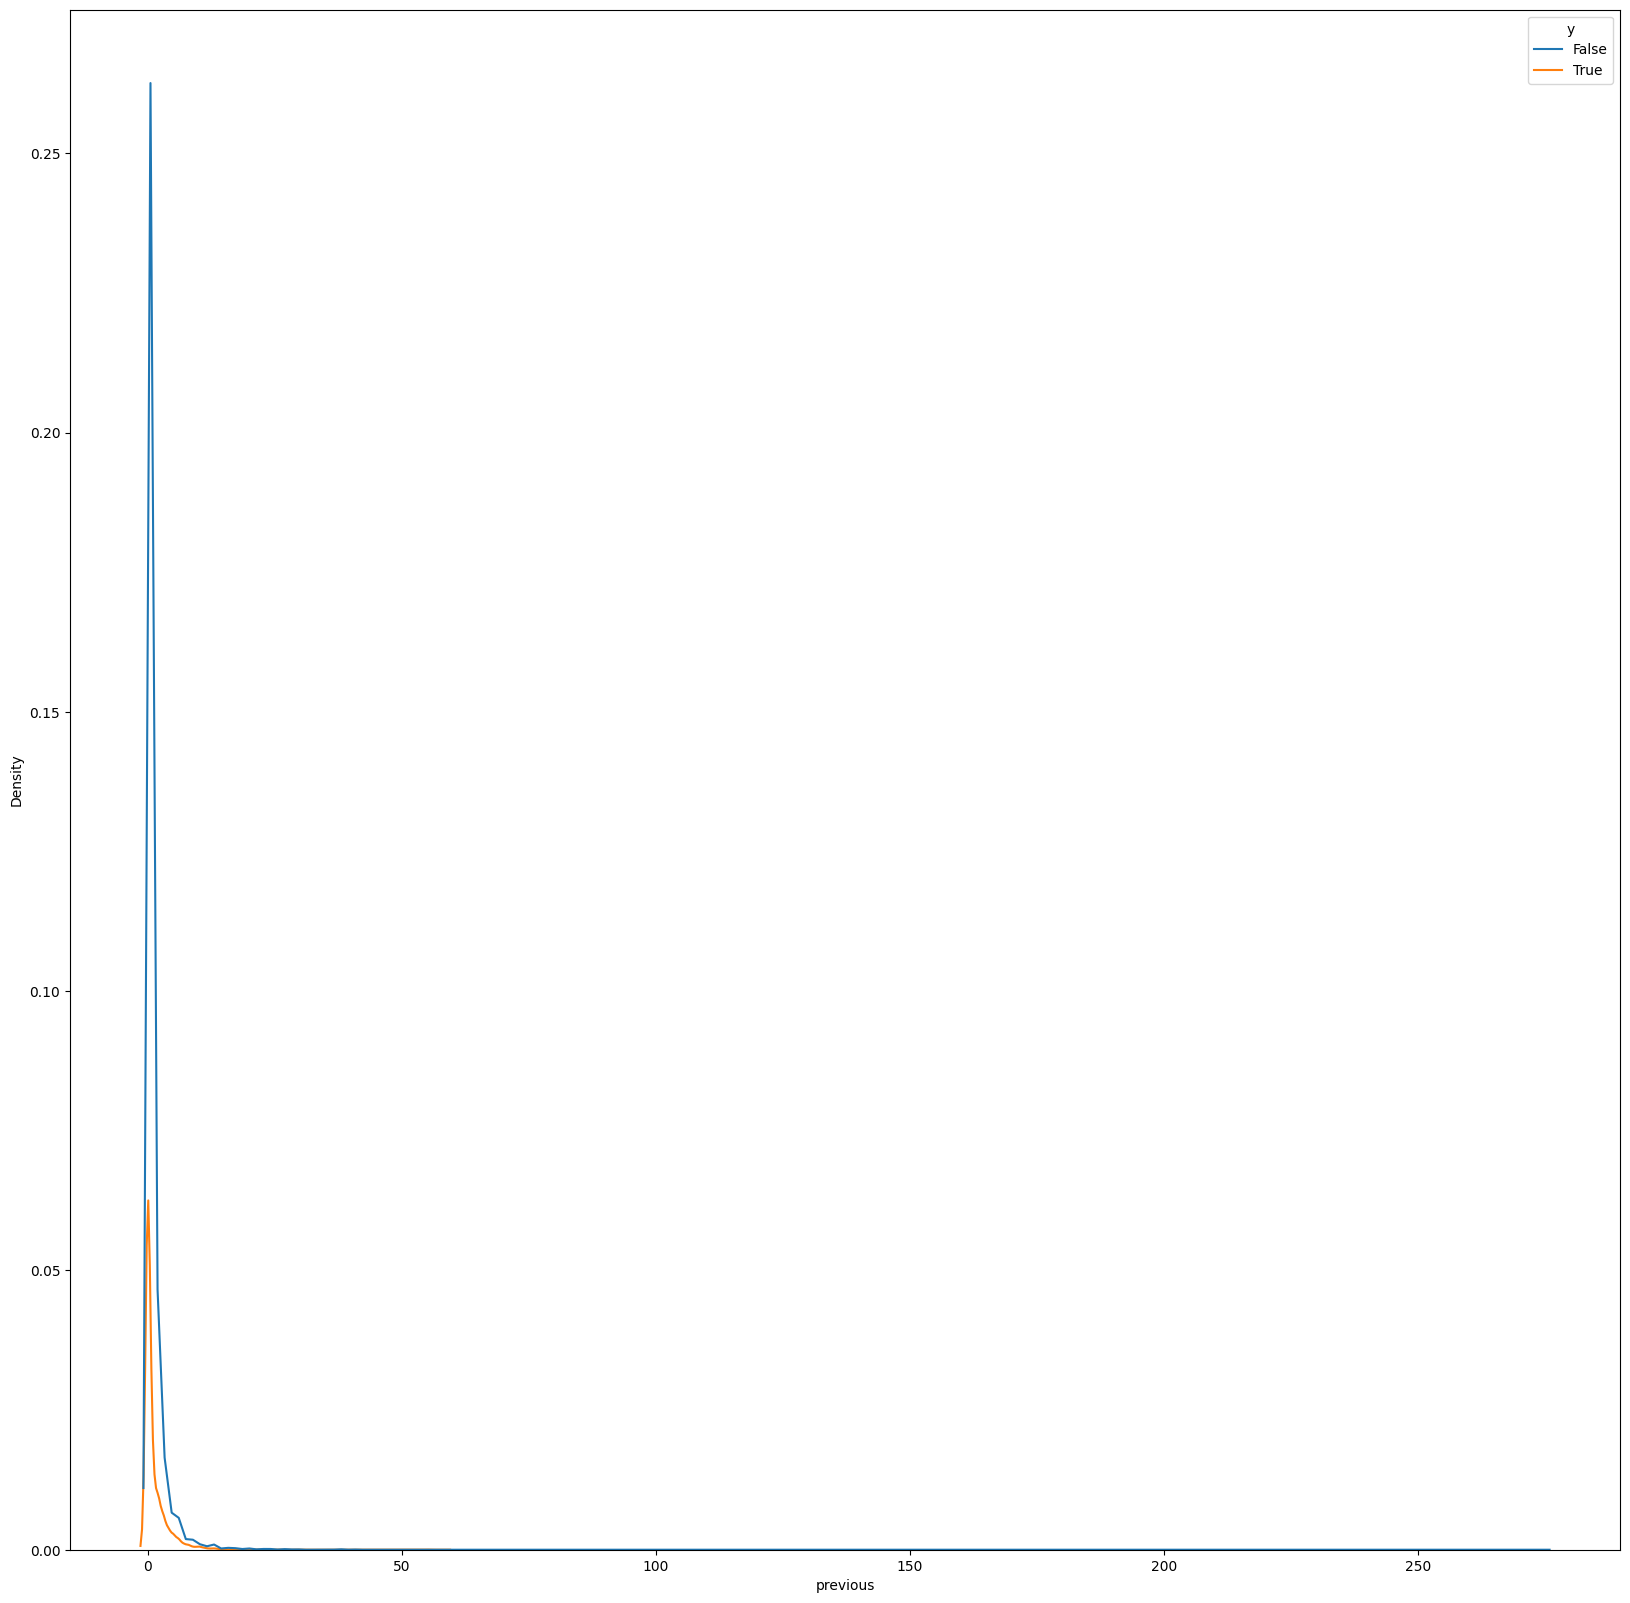

In [153]:
for col in col_num:
    fig = plt.figure(figsize=(20, 20))
    sns.kdeplot(data=train, x=col, hue=target);

In [154]:
train = pd.get_dummies(train)
test = pd.get_dummies(test)
train

,age,balance,day,duration,campaign,pdays,previous,y,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
24001,36,861,29,140,2,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
43409,24,4126,5,907,4,185,7,True,False,False,...,False,False,False,False,False,False,True,False,False,False
20669,44,244,12,1735,4,-1,0,True,False,False,...,False,False,False,False,False,False,False,False,False,True
18810,48,0,31,35,11,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
23130,38,257,26,57,10,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17958,50,917,30,58,2,-1,0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
15941,36,22,22,77,5,-1,0,False,True,False,...,False,False,False,False,False,False,False,False,False,True
16952,45,79,25,98,1,-1,0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
34781,27,2559,6,227,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,False,True


In [155]:
y_train = train[target]
X_train = train.drop(columns=target)

y_test = test[target]
X_test = test.drop(columns=target)

In [156]:
model_tree = tree.DecisionTreeClassifier()

model_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [157]:
print(metrics.classification_report(y_train, model_tree.predict(X_train)))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00     31937
        True       1.00      1.00      1.00      4231

    accuracy                           1.00     36168
   macro avg       1.00      1.00      1.00     36168
weighted avg       1.00      1.00      1.00     36168



In [158]:
print(metrics.classification_report(y_test, model_tree.predict(X_test)))

              precision    recall  f1-score   support

       False       0.93      0.93      0.93      7985
        True       0.47      0.49      0.48      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.71      0.71      9043
weighted avg       0.88      0.88      0.88      9043



In [159]:
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None], # Profundidad máxima del árbol.
    'min_samples_split': [2, 5, 10, 20], # Número mínimo de muestras necesarias para dividir un nodo interno.
    'min_samples_leaf': [1, 2, 5, 10], # Número mínimo de muestras que debe tener una hoja.
    'max_features': [None, 'sqrt', 'log2'], # Número máximo de características a considerar en cada división.
    'max_leaf_nodes': [10, 20, 50, 100, None], # Número máximo de nodos hoja.
    'criterion': ['gini', 'entropy'] # Función que mide la calidad de una división.
}
grid_search = model_selection.GridSearchCV(model_tree,
                                           param_grid,
                                           cv=10, 
                                           scoring='accuracy',
                                           n_jobs=-1,
                                           verbose=3
                                           )

grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 2880 candidates, totalling 28800 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, 20, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'max_leaf_nodes': [10, 20, 50, 100, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy', verbose=3)

In [160]:
print(metrics.classification_report(y_train, grid_search.best_estimator_.predict(X_train)))

              precision    recall  f1-score   support

       False       0.94      0.97      0.95     31937
        True       0.68      0.52      0.59      4231

    accuracy                           0.92     36168
   macro avg       0.81      0.74      0.77     36168
weighted avg       0.91      0.92      0.91     36168



In [161]:
print(metrics.classification_report(y_test, grid_search.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

       False       0.93      0.96      0.94      7985
        True       0.60      0.45      0.51      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.71      0.73      9043
weighted avg       0.89      0.90      0.89      9043



In [162]:
model_lr = linear_model.LogisticRegression(max_iter=10000)

model_lr.fit(X_train, y_train)

c:\Users\phbas\Documents\Bootcamp_Data_Science\DS_Online_PedroHBas\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=10000)

In [163]:
print(metrics.classification_report(y_train, model_lr.predict(X_train)))

              precision    recall  f1-score   support

       False       0.92      0.98      0.95     31937
        True       0.65      0.35      0.45      4231

    accuracy                           0.90     36168
   macro avg       0.79      0.66      0.70     36168
weighted avg       0.89      0.90      0.89     36168



In [164]:
print(metrics.classification_report(y_test, model_lr.predict(X_test)))

              precision    recall  f1-score   support

       False       0.92      0.97      0.95      7985
        True       0.65      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



In [165]:
train_no = train[~train[target]]
train_si = train[train[target]]

print(len(train_no))
print(len(train_si))

31937
4231


In [166]:
train_reducido = pd.concat([
                            utils.resample(train_no, replace=False, n_samples=5000, random_state=42),
                            train_si])

train_reducido

,age,balance,day,duration,campaign,pdays,previous,y,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
17361,53,2267,28,57,6,-1,0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
25805,31,883,19,168,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
16522,59,204,23,286,2,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
38576,34,-184,15,80,3,352,1,False,False,False,...,False,False,True,False,False,False,False,True,False,False
28398,37,1152,29,222,1,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40438,39,19,2,503,2,147,5,True,True,False,...,False,False,False,False,False,False,False,False,True,False
34325,31,636,4,352,4,-1,0,True,False,False,...,False,False,True,False,False,False,False,False,False,True
41939,41,431,22,133,1,107,2,True,False,False,...,False,False,False,False,True,False,False,False,True,False
34037,32,4733,30,532,1,-1,0,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [167]:
y_train = train_reducido[target]
X_train = train_reducido.drop(columns=target)

In [168]:
model_tree = tree.DecisionTreeClassifier()

model_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [169]:
print(metrics.classification_report(y_train, model_tree.predict(X_train)))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      5000
        True       1.00      1.00      1.00      4231

    accuracy                           1.00      9231
   macro avg       1.00      1.00      1.00      9231
weighted avg       1.00      1.00      1.00      9231



In [170]:
print(metrics.classification_report(y_test, model_tree.predict(X_test)))

              precision    recall  f1-score   support

       False       0.96      0.82      0.88      7985
        True       0.35      0.75      0.48      1058

    accuracy                           0.81      9043
   macro avg       0.66      0.78      0.68      9043
weighted avg       0.89      0.81      0.83      9043



In [171]:
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None], # Profundidad máxima del árbol.
    'min_samples_split': [2, 5, 10, 20], # Número mínimo de muestras necesarias para dividir un nodo interno.
    'min_samples_leaf': [1, 2, 5, 10], # Número mínimo de muestras que debe tener una hoja.
    'max_features': [None, 'sqrt', 'log2'], # Número máximo de características a considerar en cada división.
    'max_leaf_nodes': [10, 20, 50, 100, None], # Número máximo de nodos hoja.
    'criterion': ['gini', 'entropy'] # Función que mide la calidad de una división.
}
grid_search = model_selection.GridSearchCV(model_tree,
                                           param_grid,
                                           cv=10, 
                                           scoring='accuracy',
                                           n_jobs=-1,
                                           verbose=3
                                           )

grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 2880 candidates, totalling 28800 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, 20, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'max_leaf_nodes': [10, 20, 50, 100, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy', verbose=3)

In [172]:
print(metrics.classification_report(y_train, grid_search.best_estimator_.predict(X_train)))

              precision    recall  f1-score   support

       False       0.92      0.84      0.88      5000
        True       0.83      0.91      0.87      4231

    accuracy                           0.87      9231
   macro avg       0.87      0.88      0.87      9231
weighted avg       0.88      0.87      0.87      9231



In [173]:
print(metrics.classification_report(y_test, grid_search.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

       False       0.98      0.81      0.89      7985
        True       0.38      0.87      0.53      1058

    accuracy                           0.82      9043
   macro avg       0.68      0.84      0.71      9043
weighted avg       0.91      0.82      0.84      9043



In [174]:
model_lr = linear_model.LogisticRegression(max_iter=10000)

model_lr.fit(X_train, y_train)

c:\Users\phbas\Documents\Bootcamp_Data_Science\DS_Online_PedroHBas\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=10000)

In [175]:
print(metrics.classification_report(y_train, model_lr.predict(X_train)))

              precision    recall  f1-score   support

       False       0.83      0.86      0.85      5000
        True       0.83      0.79      0.81      4231

    accuracy                           0.83      9231
   macro avg       0.83      0.83      0.83      9231
weighted avg       0.83      0.83      0.83      9231



In [176]:
print(metrics.classification_report(y_test, model_lr.predict(X_test)))

              precision    recall  f1-score   support

       False       0.97      0.87      0.91      7985
        True       0.44      0.78      0.56      1058

    accuracy                           0.86      9043
   macro avg       0.70      0.82      0.74      9043
weighted avg       0.91      0.86      0.87      9043



In [177]:
train_aumentado = pd.concat([
                            utils.resample(train_si, replace=True, n_samples=32000, random_state=42),
                            train_no])

train_aumentado

,age,balance,day,duration,campaign,pdays,previous,y,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
32312,44,294,16,165,3,-1,0,True,False,False,...,False,False,False,False,False,False,False,False,False,True
41904,36,480,20,213,1,-1,0,True,False,False,...,False,False,False,False,True,False,False,False,False,True
19006,41,515,5,837,2,-1,0,True,False,False,...,False,False,False,False,False,False,False,False,False,True
44510,61,1853,10,520,1,181,2,True,False,False,...,False,False,False,False,False,False,False,False,True,False
14889,27,451,16,652,1,-1,0,True,True,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,41,1113,9,388,12,-1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
17958,50,917,30,58,2,-1,0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
15941,36,22,22,77,5,-1,0,False,True,False,...,False,False,False,False,False,False,False,False,False,True
16952,45,79,25,98,1,-1,0,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [178]:
y_train = train_aumentado[target]
X_train = train_aumentado.drop(columns=target)

In [179]:
model_tree = tree.DecisionTreeClassifier()

model_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [180]:
print(metrics.classification_report(y_train, model_tree.predict(X_train)))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00     31937
        True       1.00      1.00      1.00     32000

    accuracy                           1.00     63937
   macro avg       1.00      1.00      1.00     63937
weighted avg       1.00      1.00      1.00     63937



In [181]:
print(metrics.classification_report(y_test, model_tree.predict(X_test)))

              precision    recall  f1-score   support

       False       0.93      0.93      0.93      7985
        True       0.47      0.45      0.46      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.69      0.70      9043
weighted avg       0.87      0.88      0.88      9043



In [182]:
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None], # Profundidad máxima del árbol.
    'min_samples_split': [2, 5, 10, 20], # Número mínimo de muestras necesarias para dividir un nodo interno.
    'min_samples_leaf': [1, 2, 5, 10], # Número mínimo de muestras que debe tener una hoja.
    'max_features': [None, 'sqrt', 'log2'], # Número máximo de características a considerar en cada división.
    'max_leaf_nodes': [10, 20, 50, 100, None], # Número máximo de nodos hoja.
    'criterion': ['gini', 'entropy'] # Función que mide la calidad de una división.
}
grid_search = model_selection.GridSearchCV(model_tree,
                                           param_grid,
                                           cv=10, 
                                           scoring='accuracy',
                                           n_jobs=-1,
                                           verbose=3
                                           )

grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 2880 candidates, totalling 28800 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, 20, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'max_leaf_nodes': [10, 20, 50, 100, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy', verbose=3)

In [183]:
print(metrics.classification_report(y_train, grid_search.best_estimator_.predict(X_train)))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00     31937
        True       1.00      1.00      1.00     32000

    accuracy                           1.00     63937
   macro avg       1.00      1.00      1.00     63937
weighted avg       1.00      1.00      1.00     63937



In [184]:
print(metrics.classification_report(y_test, grid_search.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

       False       0.93      0.94      0.93      7985
        True       0.49      0.46      0.47      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.70      0.70      9043
weighted avg       0.88      0.88      0.88      9043



In [185]:
model_lr = linear_model.LogisticRegression(max_iter=10000)

model_lr.fit(X_train, y_train)

c:\Users\phbas\Documents\Bootcamp_Data_Science\DS_Online_PedroHBas\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=10000)

In [186]:
print(metrics.classification_report(y_test, model_lr.predict(X_test)))

              precision    recall  f1-score   support

       False       0.97      0.85      0.91      7985
        True       0.41      0.82      0.55      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.91      0.84      0.86      9043



In [187]:
train_balanceado = pd.concat([
                            utils.resample(train_no, replace=False, n_samples=10000, random_state=42),
                            utils.resample(train_si, replace=True, n_samples=10000, random_state=42),
                            ])

train_balanceado

,age,balance,day,duration,campaign,pdays,previous,y,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
17361,53,2267,28,57,6,-1,0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
25805,31,883,19,168,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
16522,59,204,23,286,2,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
38576,34,-184,15,80,3,352,1,False,False,False,...,False,False,True,False,False,False,False,True,False,False
28398,37,1152,29,222,1,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31080,44,397,16,127,1,257,1,True,True,False,...,False,False,False,False,False,False,False,True,False,False
13057,31,296,8,509,4,-1,0,True,False,False,...,False,False,False,False,False,False,False,False,False,True
44050,74,29080,30,301,5,93,4,True,False,False,...,True,False,False,False,False,False,False,True,False,False
17399,54,1938,28,551,3,-1,0,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [188]:
y_train = train_balanceado[target]
X_train = train_balanceado.drop(columns=target)

In [189]:
model_tree = tree.DecisionTreeClassifier()

model_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [190]:
print(metrics.classification_report(y_train, model_tree.predict(X_train)))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00     10000
        True       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [191]:
print(metrics.classification_report(y_test, model_tree.predict(X_test)))

              precision    recall  f1-score   support

       False       0.95      0.87      0.91      7985
        True       0.39      0.63      0.49      1058

    accuracy                           0.84      9043
   macro avg       0.67      0.75      0.70      9043
weighted avg       0.88      0.84      0.86      9043



In [192]:
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None], # Profundidad máxima del árbol.
    'min_samples_split': [2, 5, 10, 20], # Número mínimo de muestras necesarias para dividir un nodo interno.
    'min_samples_leaf': [1, 2, 5, 10], # Número mínimo de muestras que debe tener una hoja.
    'max_features': [None, 'sqrt', 'log2'], # Número máximo de características a considerar en cada división.
    'max_leaf_nodes': [10, 20, 50, 100, None], # Número máximo de nodos hoja.
    'criterion': ['gini', 'entropy'] # Función que mide la calidad de una división.
}
grid_search = model_selection.GridSearchCV(model_tree,
                                           param_grid,
                                           cv=10, 
                                           scoring='accuracy',
                                           n_jobs=-1,
                                           verbose=3
                                           )

grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 2880 candidates, totalling 28800 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, 20, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'max_leaf_nodes': [10, 20, 50, 100, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy', verbose=3)

In [193]:
print(metrics.classification_report(y_train, grid_search.best_estimator_.predict(X_train)))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00     10000
        True       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [194]:
print(metrics.classification_report(y_test, grid_search.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

       False       0.95      0.87      0.91      7985
        True       0.39      0.63      0.48      1058

    accuracy                           0.84      9043
   macro avg       0.67      0.75      0.70      9043
weighted avg       0.88      0.84      0.86      9043



In [195]:
model_lr = linear_model.LogisticRegression(max_iter=10000)

model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [196]:
print(metrics.classification_report(y_test, model_lr.predict(X_test)))

              precision    recall  f1-score   support

       False       0.97      0.85      0.91      7985
        True       0.41      0.81      0.55      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.91      0.84      0.86      9043

